In [ ]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

def get_trafic_bpr(flow, t0, alpha, capacity, beta, max_cost):
    #t0 new limit
    ratio = flow / capacity
    cost = t0 * (1 + alpha * (ratio**beta))
    return np.clip(cost, 0, max_cost)

def wth_memory_pro(record_array, b, t0):
    if record_array.size == 0:
        return t0
    r_aux = np.concatenate(([t0, t0], record_array))
    n = len(r_aux)
    indices = np.arange(n)[::-1]
    weights = np.exp(-b * indices)
    return np.average(r_aux, weights=weights)

def initialize_variable_graph(n, seed_val, t0_val):
    G = nx.grid_2d_graph(n, n)
    for u, v in G.edges():
        G[u][v]['cars_count_today'] = 0
        G[u][v]['capacity'] = random.choice([15, 30, 50])
        #now its based in the T0 of limit
        initial_noise = np.random.uniform(1.0, 1.8, size=2)
        G[u][v]['record'] = np.array(t0_val * initial_noise, dtype=np.float64)
    return G

def create_agents(G, agents_per_node, seed_val):
    nodes = list(G.nodes())
    agents = []
    for _ in range(len(nodes) * agents_per_node):
        o, d = random.sample(nodes, 2)
        agents.append({'origen': o, 'destination': d})
    return agents

In [ ]:
#CONFIG AND SEED
SEED=42
CONFIG = {
    'N_GRID':10, #grid size
    'DAYS':100, #days to measure the experiment
    'AGENTS_NODE':10, #agents per node
    'B_FORG':0.3, #controls the memory of the agents if it is low they have a really good memory
    'T0_LIMIT': 8, #base cost of crossing an empty street
    'ALPHA':0.15, #controls how fats the trafic jams are afecting, if we raise it it afects more
    'BETA':4, #this value mantains the cost close to t0 till it can not handle the jam anymore
    'COST_BUS_STR':12, #cost of time if you pick the bus
    'THETA':0.5, #how rational the agents are, if it is low they are not that rational and not always pick the lowest time transport
    'MAX_COST_STR':200  #the top time it gets to cross an street it will never be higher than 200
}

In [ ]:
#SIMULATION
random.seed(SEED)
np.random.seed(SEED)

G = initialize_variable_graph(CONFIG['N_GRID'], SEED, CONFIG['T0_LIMIT'])
agents = create_agents(G, CONFIG['AGENTS_NODE'], SEED)

car_record = np.zeros(CONFIG['DAYS'])
bus_record = np.zeros(CONFIG['DAYS'])
time_record = np.zeros(CONFIG['DAYS'])

for day in range(1, CONFIG['DAYS'] + 1):
    for u, v in G.edges(): G[u][v]['cars_count_today'] = 0
    random.shuffle(agents)
    c_count, b_count = 0, 0
    t_tdy = []
    daily_base_weights = {} #the basic cost is the same, we apply the individual aspects in the for a in agents
    for u, v, d in G.edges(data=True):
        daily_base_weights[(u, v)] = wth_memory_pro(d['record'], CONFIG['B_FORG'], CONFIG['T0_LIMIT'])

    for a in agents:
        pair = (a['origen'], a['destination'])
        #we apply an specific weight for each agent
        agent_weights={}
        for (u, v), base_w in daily_base_weights.items():
            agent_weights[(u, v)] = base_w * np.random.uniform(0.98, 1.02)
        #then we calculate the route
        route = nx.shortest_path(G, pair[0], pair[1], weight=lambda u, v, d: agent_weights.get((u, v), agent_weights.get((v, u))))
        cost_c_est = sum([agent_weights.get((u, v), agent_weights.get((v, u))) for u, v in zip(route[:-1], route[1:])])
        dist = len(route) - 1
        cost_bus = dist * CONFIG['COST_BUS_STR']
        prob_c = 1 / (1 + np.exp(-CONFIG['THETA'] * (cost_bus - cost_c_est)))

        if np.random.random() < prob_c:
            c_count += 1
            t_trip = 0
            for i in range(len(route)-1):
                u, v = route[i], route[i+1]
                t_tram = get_trafic_bpr(G[u][v]['cars_count_today'], CONFIG['T0_LIMIT'], CONFIG['ALPHA'], G[u][v]['capacity'], CONFIG['BETA'], CONFIG['MAX_COST_STR'])
                t_trip += t_tram
                G[u][v]['cars_count_today'] += 1
            t_tdy.append(t_trip)
        else:
            b_count += 1
            t_tdy.append(dist * CONFIG['COST_BUS_STR'])

    for u, v in G.edges():
        real_c = get_trafic_bpr(G[u][v]['cars_count_today'], CONFIG['T0_LIMIT'], CONFIG['ALPHA'], G[u][v]['capacity'], CONFIG['BETA'], CONFIG['MAX_COST_STR'])
        G[u][v]['record'] = np.append(G[u][v]['record'], real_c)

    idx = day - 1
    car_record[idx], bus_record[idx], time_record[idx] = c_count, b_count, np.mean(t_tdy)
    print(f"Day {day:2}: Car = {c_count:4} | Bus = {b_count:4} | Average = {time_record[idx]:.2f}")


#graph and test export
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(car_record, label="Car (Demand)", color='red')
ax1.plot(bus_record, label="Bus (Demand)", color='blue')
ax1.set_title(f"Evolution of the demand")
ax1.set_ylabel("Number of users")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(time_record, color='green')
ax2.set_title(f"Evolution of the average time ")
ax2.set_ylabel("Average time"); ax2.set_xlabel("Day"); ax2.grid(True, alpha=0.3)

plt.tight_layout()

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = f"learning{CONFIG['B_FORG']}"

fig.savefig(f"{base_filename}_grafico.png", dpi=300, bbox_inches='tight')
df = pd.DataFrame({
    'Day': np.arange(1, CONFIG['DAYS'] + 1),
    'Car': car_record, 'Bus': bus_record, 'Average_time': time_record
})
df.to_csv(f"{base_filename}.csv", index=False, sep=';', encoding='utf-8-sig')

plt.show()

Day  1: Car =  970 | Bus =   30 | Average = 236.03
Day  2: Car =  920 | Bus =   80 | Average = 246.78
Day  3: Car =  490 | Bus =  510 | Average = 171.76
Day  4: Car =  271 | Bus =  729 | Average = 94.48
Day  5: Car =  221 | Bus =  779 | Average = 84.84
Day  6: Car =  289 | Bus =  711 | Average = 75.15
Day  7: Car =  456 | Bus =  544 | Average = 82.97
Day  8: Car =  471 | Bus =  529 | Average = 71.43


KeyboardInterrupt: 

The generic simulation is over, and, in order to create a more "realistic" city, we add a new model of epicentric city, where most of the people lives outside the center of the city and comutes there everyday.

In [ ]:
#SIMULATION EPICENTRIC CITY
def create_agents_radiocentric(G, agents_per_node, seed_val):
    random.seed(seed_val)
    nodes = list(G.nodes())
    n_size = int(len(nodes)**0.5) #square grid
    #limits of the center, this can me change:
    c_min=int(n_size * 0.3)
    c_max=int(n_size * 0.7)
    center=[n for n in nodes if c_min <= n[0] <= c_max and c_min <= n[1] <= c_max]
    periphery=[n for n in nodes if n not in center]
    agents = []
    total_agents = len(nodes) * agents_per_node
    #we add this to keep track of real numbers of how many agents are and are going tpo each zone
    a_center_center = 0
    a_center_periph = 0
    a_periph_center = 0
    a_periph_periph = 0
    for agent in range(total_agents):
        rand_origen = random.random()
        rand_destino = random.random()
        #80% are from the peryphery so we pick if they go to the center or to the peryphery
        if rand_origen < 0.80:
            o = random.choice(periphery)
            if rand_destino < 0.80:
                d = random.choice(center)
                a_periph_center += 1
            else:
                d = random.choice(periphery)
                while d == o: d = random.choice(periphery) #here we avoid them staying in the same place
                a_periph_periph += 1
        else:
            o = random.choice(center)
            if rand_destino < 0.90:
                d = random.choice(center)
                while d == o: d = random.choice(center) #here we avoid them staying in the same place
                a_center_center+= 1
            else:
                d=random.choice(periphery)
                a_center_periph += 1
        agents.append({'origen': o, 'destination': d})
    print(f"Agents created: {len(agents)}")
    print(f"Center zone defined by coordinates between {c_min} and {c_max}")
    print(f"*Periphery --> Center:{a_periph_center} agents")
    print(f"*Periphery --> Periphery:{a_periph_periph} agents")
    print(f"*Center --> Center:{a_center_center} agents")
    print(f"*Center --> Periphery:{a_center_periph} agents")

    return agents

In [ ]:
def plot_city_structure(G, n_size):
    c_min=int(n_size * 0.3)
    c_max=int(n_size * 0.7)
    pos={node: node for node in G.nodes()}
    node_colors=[]
    for n in G.nodes():
        if c_min <= n[0] <= c_max and c_min <= n[1] <= c_max:
            node_colors.append('orange') #center
        else:
            node_colors.append('skyblue')
    plt.figure(figsize=(8, 8))
    nx.draw(G, pos,
            node_color=node_colors,
            with_labels=False,
            node_size=100,
            edge_color='gray',
            alpha=0.7)
    from matplotlib.lines import Line2D
    legend_elements=[
        Line2D([0], [0], marker='o', color='w', label='Periphery', markerfacecolor='skyblue', markersize=10),
        Line2D([0], [0], marker='o', color='w', label='Center', markerfacecolor='orange', markersize=10)]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.title(f"City structure (Grid {n_size}x{n_size})")
    plt.show()

plot_city_structure(G, CONFIG['N_GRID'])

In [ ]:
#SIMULATION WHEN EPICENTRIC CITY
random.seed(SEED)
np.random.seed(SEED)
G = initialize_variable_graph(CONFIG['N_GRID'], SEED, CONFIG['T0_LIMIT'])
agents = create_agents_radiocentric(G, CONFIG['AGENTS_NODE'], SEED)

#agents in the center
n_size = CONFIG['N_GRID']
c_min, c_max = int(n_size * 0.3), int(n_size * 0.7)
car_record = np.zeros(CONFIG['DAYS'])   #how many cars
bus_record = np.zeros(CONFIG['DAYS'])   #how many buses
time_record = np.zeros(CONFIG['DAYS'])  #time record average every day

#keep track of what people in the center and in the perif
center_car_rec = np.zeros(CONFIG['DAYS'])
center_bus_rec = np.zeros(CONFIG['DAYS'])
periph_car_rec = np.zeros(CONFIG['DAYS'])
periph_bus_rec = np.zeros(CONFIG['DAYS'])

for day in range(1, CONFIG['DAYS'] + 1):
    for u, v in G.edges(): G[u][v]['cars_count_today'] = 0
    random.shuffle(agents)
    c_count = 0
    b_count = 0
    c_center = 0
    b_center = 0
    c_periph = 0
    b_periph = 0
    t_tdy = []
    daily_base_weights = {}
    for u, v, d in G.edges(data=True):
        daily_base_weights[(u, v)] = wth_memory_pro(d['record'], CONFIG['B_FORG'], CONFIG['T0_LIMIT'])

    for a in agents:
        orig = a['origen']
        pair = (orig, a['destination'])
        is_center = (c_min <= orig[0] <= c_max) and (c_min <= orig[1] <= c_max)
        #we apply an specific weight for each agent
        agent_weights={}
        for (u, v), base_w in daily_base_weights.items():
            agent_weights[(u, v)] = base_w * np.random.uniform(0.98, 1.02)
        #then we calculate the route
        route = nx.shortest_path(G, pair[0], pair[1],
                                 weight=lambda u, v, d: agent_weights.get((u, v), agent_weights.get((v, u))))
        cost_c_est = sum([agent_weights.get((u, v), agent_weights.get((v, u))) for u, v in zip(route[:-1], route[1:])])
        dist = len(route) - 1
        cost_bus = dist * CONFIG['COST_BUS_STR']
        prob_c = 1 / (1 + np.exp(-CONFIG['THETA'] * (cost_bus - cost_c_est)))
        if np.random.random() < prob_c:
            c_count += 1
            if is_center:
                c_center += 1
            else:
                c_periph += 1
            t_trip = 0
            for i in range(len(route)-1):
                u = route[i]
                v = route[i+1]
                t_tram = get_trafic_bpr(G[u][v]['cars_count_today'], CONFIG['T0_LIMIT'], CONFIG['ALPHA'], G[u][v]['capacity'], CONFIG['BETA'], CONFIG['MAX_COST_STR'])
                t_trip += t_tram
                G[u][v]['cars_count_today'] += 1
            t_tdy.append(t_trip)
        else:
            b_count += 1
            if is_center:
                b_center += 1
            else:
                b_periph += 1
            t_tdy.append(dist * CONFIG['COST_BUS_STR'])

    for u, v in G.edges():
        real_c = get_trafic_bpr(G[u][v]['cars_count_today'], CONFIG['T0_LIMIT'], CONFIG['ALPHA'], G[u][v]['capacity'], CONFIG['BETA'], CONFIG['MAX_COST_STR'])
        G[u][v]['record'] = np.append(G[u][v]['record'], real_c)

    idx = day - 1
    car_record[idx], bus_record[idx], time_record[idx] = c_count, b_count, np.mean(t_tdy)
    center_car_rec[idx] = c_center
    center_bus_rec[idx] = b_center
    periph_car_rec[idx] = c_periph
    periph_bus_rec[idx] = b_periph
    print(f"Day {day:2}: Car = {c_count:4} | Bus = {b_count:4} | Center(C/B): {c_center}/{b_center} | Periphery(C/B): {c_periph}/{b_periph} | Average = {time_record[idx]:.2f}")


#graphs
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

#total graph
axs[0, 0].plot(car_record, label="Total cars", color='red')
axs[0, 0].plot(bus_record, label="Total bus", color='blue')
axs[0, 0].set_title("Global Demand")
axs[0, 0].set_ylabel("Number of agents/users")
axs[0, 0].legend(); axs[0, 0].grid(True, alpha=0.3)

#center population
axs[0, 1].plot(center_car_rec, label="Car (Center agents)", color='darkorange')
axs[0, 1].plot(center_bus_rec, label="Bus (Center agents)", color='cyan')
axs[0, 1].set_title("Center agents")
axs[0, 1].set_ylabel("Number of agents/users")
axs[0, 1].legend(); axs[0, 1].grid(True, alpha=0.3)

#periphery population
axs[1, 0].plot(periph_car_rec, label="Car (Periphery agents)", color='crimson')
axs[1, 0].plot(periph_bus_rec, label="Bus (Periphery agents)", color='navy')
axs[1, 0].set_title("Periphery agents")
axs[1, 0].set_ylabel("Number of agents/users")
axs[1, 0].set_xlabel("Day")
axs[1, 0].legend(); axs[1, 0].grid(True, alpha=0.3)

#average trip
axs[1, 1].plot(time_record, color='green', label="Tiempo Medio")
axs[1, 1].set_title(f"Evolution of time")
axs[1, 1].set_ylabel("Time of trip")
axs[1, 1].set_xlabel("Day")
axs[1, 1].legend(); axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

#to save the simulations and graphs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename =base_filename = f"learning_test_center_grid{CONFIG['B_FORG']}"
fig.savefig(f"{base_filename}_panel_graficos.png", dpi=300, bbox_inches='tight')

for i, name in enumerate(["global", "center", "periphery", "time"]):
    extent = axs[i//2, i%2].get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(f"{base_filename}_grafico_{name}.png", bbox_inches=extent.expanded(1.1, 1.1), dpi=300)

df = pd.DataFrame({
    'Day': np.arange(1, CONFIG['DAYS'] + 1),
    'Total_Cars': car_record,
    'Total_Bus': bus_record,
    'Center_Cars': center_car_rec,
    'Center_Bus': center_bus_rec,
    'Periphery_Cars': periph_car_rec,
    'Periphery_Bus': periph_bus_rec,
    'Average_time': time_record
})
df.to_csv(f"{base_filename}.csv", index=False, sep=';', encoding='utf-8-sig')

plt.show()

Here we star with the actuall representation of Zaragoza

In [1]:
#we install this library to create our graph
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.2 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
from shapely.geometry import shape
geojson_zaragoza = {
  "type": "Feature",
  "properties": {},
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [-0.916672, 41.73589],
        [-0.98877, 41.705652],
        [-1.009369, 41.682066],
        [-1.012115, 41.667193],
        [-1.006622, 41.648724],
        [-0.995636, 41.630764],
        [-0.98671, 41.616905],
        [-0.959244, 41.608691],
        [-0.929718, 41.601503],
        [-0.85968, 41.597396],
        [-0.837708, 41.607665],
        [-0.807495, 41.628198],
        [-0.801315, 41.656933],
        [-0.801315, 41.68463],
        [-0.823288, 41.717441],
        [-0.834961, 41.738452],
        [-0.916672, 41.73589]
      ]
    ]
  }
}

poligono_final = shape(geojson_zaragoza['geometry'])
#we keep primary roads
custom_filter = (
    '["highway"~"motorway|trunk|primary|secondary|tertiary|'
    'motorway_link|trunk_link|primary_link|secondary_link|tertiary_link"]'
)
#we add the custom filter
G_nativo = ox.graph_from_polygon(poligono_final, custom_filter=custom_filter)
#we keep the largest strongly connected component
G_saneado = ox.truncate.largest_component(G_nativo, strongly=True)
G_zaragoza_real = nx.DiGraph(G_saneado) #it has to be directed
print(f"Real intersections (nodes): {G_zaragoza_real.number_of_nodes()}")
print(f"Segments of streets connected (edges): {G_zaragoza_real.number_of_edges()}")

Real intersections (nodes): 1953
Segments of streets connected (edges): 3251


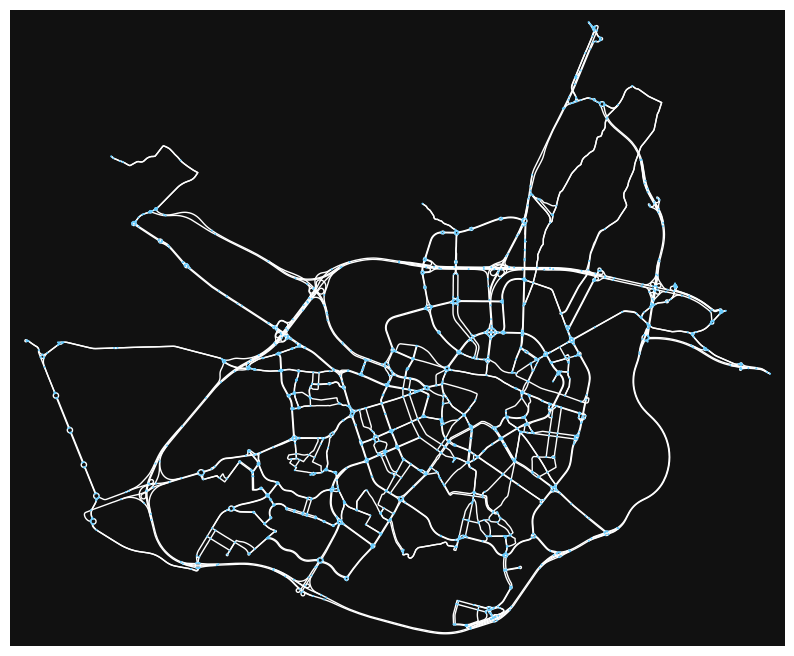

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [ ]:
#plot of the selected zone
ox.plot_graph(G_saneado, node_size=2, node_color='#66ccff', edge_color='#ffffff', bgcolor='#111111', figsize=(10,10))

To star the simulation and try to implement the same "code" as the simple model, or at least the closets one, we separate this code in 3 parts. General functions, parameters and simulation

In [3]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import osmnx as ox
#progress bar:
from tqdm.notebook import tqdm

def get_trafic_bpr(flow, t0, alpha, capacity, beta, max_cost):
    ratio = flow / capacity
    cost = t0 * (1 + alpha * (ratio**beta))
    return np.clip(cost, 0, max_cost)

def wth_memory_pro(record_array, b, t0):
    if record_array.size == 0:
        return t0
    r_aux = np.concatenate(([t0, t0], record_array))
    n = len(r_aux)
    indices = np.arange(n)[::-1]
    weights = np.exp(-b * indices)
    return np.average(r_aux, weights=weights)

def prepare_zaragoza_graph(G_directed, alpha_val, max_cost_val):
    #we add this to get percentages and numbers of how many things we are missing
    total_edges=G_directed.number_of_edges()
    missing_lanes=0
    missing_maxspeed=0
    missing_length=0
    #lanes
    for u, v, data in G_directed.edges(data=True):
        lanes_raw=data.get('lanes', None)
        if lanes_raw is None:
            missing_lanes += 1
            lanes=1
        elif isinstance(lanes_raw, list):
            try: lanes=int(lanes_raw[0])
            except:
                missing_lanes+=1
                lanes=1
        else:
            try: lanes=int(lanes_raw)
            except:
                missing_lanes+=1
                lanes=1
        #speed
        maxspeed_raw = data.get('maxspeed', None)
        if maxspeed_raw is None:
            missing_maxspeed+=1
            maxspeed_kmh=30
        else:
            if isinstance(maxspeed_raw, list):
                maxspeed_raw=maxspeed_raw[0]
            try:
                maxspeed_kmh = int(''.join(filter(str.isdigit, str(maxspeed_raw))))
            except:
                missing_maxspeed += 1
                maxspeed_kmh = 30
        maxspeed_ms = maxspeed_kmh / 3.6
        #length
        length_raw = data.get('length', None)
        if length_raw is None:
            missing_length += 1
            length=50.0
        else:
            try:
                length = float(length_raw)
            except:
                missing_length += 1
                length = 50.0
        #real capacity
        data['capacity'] = max(2, int((length / 6.0) * lanes))
        #t0
        data['t0_real'] = length / maxspeed_ms
        data['cars_count_today'] = 0
        initial_noise = np.random.uniform(1.0, 1.8, size=2)
        data['record'] = np.array(data['t0_real'] * initial_noise, dtype=np.float64)
    print(f"Total edges: {total_edges}")
    print(f"Lanes:     {missing_lanes:6d} edges ({missing_lanes/total_edges*100:6.2f}%) -> normal value: 1")
    print(f"Maxspeed missing: {missing_maxspeed:6d} edges ({missing_maxspeed/total_edges*100:6.2f}%) -> normal value: 30 km/h")
    print(f"Length missing:     {missing_length:6d} edges ({missing_length/total_edges*100:6.2f}%) -> normal value: 50 m")
    print("=" * 65)

    return G_directed

def create_real_agents(G_directed, total_agents, seed_val=None):
    #create agents
    if seed_val is not None:
        random.seed(seed_val)
    nodes = list(G_directed.nodes())
    agents = []
    for _ in range(total_agents):
        o, d = random.sample(nodes, 2)
        agents.append({'origen': o, 'destination': d})
    return agents

In [4]:
#seed and configuration for the city
SEED = 42
CONFIG = {
    'DAYS': 50, #days to measure the experiment
    'TOTAL_AGENTS': 35000, #total agents
    'B_FORG': 0.3,  #controls the memory of the agents if it is low they have a really good memory
    'ALPHA': 0.15, #controls how fats the trafic jams are afecting, if we raise it it afects more
    'BETA': 4,  #this value mantains the cost close to t0 till it can not handle the jam anymore
    'COST_BUS_STR': 45.0,  #cost of time if you pick the bus
    'THETA': 0.5,  #how rational the agents are, if it is low they are not that rational and not always pick the lowest time transport
    'MAX_COST_STR': 1200,  #the top time it gets to cross an street it will never be higher than 200
    'BUS_WAIT_TIME': 450,      #waiting time
    'BUS_CRUISE_SPEED' : 4.16,  #bus speed 15 km/h
    'BUS_STOP_DENSITY': 400.0, #a stop every X meters
    'BUS_DWELL_TIME': 25.0 #the penalty for every stop
}

In [ ]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
from tqdm import tqdm

#SIMULATION
random.seed(SEED)
np.random.seed(SEED)
G_sim = prepare_zaragoza_graph(G_zaragoza_real, CONFIG['ALPHA'], CONFIG['MAX_COST_STR'])
agents = create_real_agents(G_sim, CONFIG['TOTAL_AGENTS'])
car_record = np.zeros(CONFIG['DAYS'])
bus_record = np.zeros(CONFIG['DAYS'])
time_record = np.zeros(CONFIG['DAYS'])

print(f"Zaragoza: ({G_sim.number_of_nodes()} nodes, {G_sim.number_of_edges()} edges)")

for day in range(1, CONFIG['DAYS'] + 1):
    for u, v in G_sim.edges():
        G_sim[u][v]['cars_count_today'] = 0

    random.shuffle(agents)
    c_count, b_count = 0, 0
    t_tdy = []

    for u, v, d in G_sim.edges(data=True):
        G_sim[u][v]['_base_weight_today'] = wth_memory_pro(d['record'], CONFIG['B_FORG'], d['t0_real'])

    route_cache = {}
    print(f"\nDay {day}/{CONFIG['DAYS']}...")

    for a in tqdm(agents, desc=f"Traveling agents", leave=False):
        origen, destino = a['origen'], a['destination']
        od_pair = (origen, destino)

        #cache lookup
        if od_pair in route_cache:
            route, cost_c_est, cost_bus_est = route_cache[od_pair]
        else:
            try:
                route = nx.shortest_path(G_sim, source=origen, target=destino, weight='_base_weight_today')
                cost_c_est = sum([G_sim[u][v]['_base_weight_today'] for u, v in zip(route[:-1], route[1:])])

                bus_travel_time = 0
                for u, v in zip(route[:-1], route[1:]):
                    length_m = G_sim[u][v].get('length', 100.0)
                    t_running = length_m / CONFIG['BUS_CRUISE_SPEED']
                    t_stops = (length_m / CONFIG['BUS_STOP_DENSITY']) * CONFIG['BUS_DWELL_TIME']
                    bus_travel_time += (t_running + t_stops)

                cost_bus_est = CONFIG['BUS_WAIT_TIME'] + bus_travel_time
                route_cache[od_pair] = (route, cost_c_est, cost_bus_est)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                route_cache[od_pair] = (None, None, None)
                route = None

        if route is None:
            b_count += 1
            continue

        cost_c_agent = cost_c_est * np.random.uniform(0.98, 1.02)
        cost_bus_agent = cost_bus_est
        exponent = -CONFIG['THETA'] * (cost_bus_agent - cost_c_agent)
        exponent_clipped = np.clip(exponent, -50.0, 50.0)
        prob_c = 1.0 / (1.0 + np.exp(exponent_clipped))
        if np.random.random() < prob_c:
            c_count += 1
            t_trip = 0
            for i in range(len(route) - 1):
                u, v = route[i], route[i+1]
                t_tram = get_trafic_bpr(
                    G_sim[u][v]['cars_count_today'],
                    G_sim[u][v]['t0_real'],
                    CONFIG['ALPHA'],
                    G_sim[u][v]['capacity'],
                    CONFIG['BETA'],
                    CONFIG['MAX_COST_STR']
                )
                t_trip += t_tram
                G_sim[u][v]['cars_count_today'] += 1.0
            t_tdy.append(t_trip)
        else:
            b_count += 1
            t_trip_car_current = sum([get_trafic_bpr(
                G_sim[u][v]['cars_count_today'],
                G_sim[u][v]['t0_real'],
                CONFIG['ALPHA'],
                G_sim[u][v]['capacity'],
                CONFIG['BETA'],
                CONFIG['MAX_COST_STR']
            ) for u, v in zip(route[:-1], route[1:])])
            #we add the congestion delay
            congestion_delay = max(0, t_trip_car_current - cost_c_est)
            t_trip_bus = cost_bus_est + (congestion_delay * 0.4)
            t_tdy.append(t_trip_bus)

    #everyday record
    for u, v in G_sim.edges():
        real_c = get_trafic_bpr(
            G_sim[u][v]['cars_count_today'],
            G_sim[u][v]['t0_real'],
            CONFIG['ALPHA'],
            G_sim[u][v]['capacity'],
            CONFIG['BETA'],
            CONFIG['MAX_COST_STR']
        )
        G_sim[u][v]['record'] = np.append(G_sim[u][v]['record'], real_c)

    idx = day - 1
    car_record[idx] = c_count
    bus_record[idx] = b_count
    time_record[idx] = np.mean(t_tdy) / 60.0 if t_tdy else 0
    print(f"Day {day:2d}: Car = {c_count:5d} | Bus = {b_count:5d} | Avg Time = {time_record[idx]:.2f} min")

#graohs
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
ax1.plot(car_record, label="Car", color='crimson', linewidth=2)
ax1.plot(bus_record, label="Bus/Tram", color='royalblue', linewidth=2)
ax1.set_title("Evolution of Modal Split in Zaragoza", fontsize=12, fontweight='bold')
ax1.set_ylabel("Number of agents")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(time_record, color='seagreen', linewidth=2)
ax2.set_title("Evolution of Average Trip Duration", fontsize=12, fontweight='bold')
ax2.set_ylabel("Average time (min)")
ax2.set_xlabel("Simulation days")
ax2.grid(True, alpha=0.3)
plt.tight_layout()

#to save the simulation and graphs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = f"sim_Zaragoza_DistanceBus_{timestamp}"
fig.savefig(f"{base_filename}_grafico.png", dpi=300, bbox_inches='tight')

df = pd.DataFrame({
    'Day': np.arange(1, CONFIG['DAYS'] + 1),
    'Car': car_record,
    'Bus': bus_record,
    'Average_time_minutes': time_record
})
df.to_csv(f"{base_filename}.csv", index=False, sep=';', encoding='utf-8-sig')
plt.show()

Now we create a epicentric city using Zaragoza to emulate a more realistic city

In [5]:
import random
import numpy as np
from pyproj import Transformer

def classify_nodes_center_periphery(G_directed, center_coords=(41.652, -0.881), radius_meters=1500):
    #central point Plaza España
    transformer = Transformer.from_crs("epsg:4326", "epsg:32630", always_xy=True)
    center_x, center_y = transformer.transform(center_coords[1], center_coords[0])
    center_nodes=[]
    periphery_nodes=[]
    for node, data in G_directed.nodes(data=True):
        node_lat=data['y']
        node_lon=data['x']
        #actual node
        node_x, node_y = transformer.transform(node_lon, node_lat)
        #euclidean distance
        distance=np.sqrt((node_x-center_x)**2+(node_y-center_y)**2)

        if distance <= radius_meters:
            data['zone'] = 'center'
            center_nodes.append(node)
        else:
            data['zone'] = 'periphery'
            periphery_nodes.append(node)
    print(f"Center nodes: {len(center_nodes)}")
    print(f"Periphery nodes: {len(periphery_nodes)}")

    return center_nodes, periphery_nodes

def create_demographic_agents(G_directed, total_agents, center_nodes, periphery_nodes, seed_val=None):
    #70% periphery -> center
    #15% center -> center
    #15% periphery -> periphery

    if seed_val is not None:
        random.seed(seed_val)
    agents=[]
    p_peri_center=int(total_agents*0.70)
    p_center_center=int(total_agents*0.15)
    p_peri_peri=total_agents-p_peri_center-p_center_center

    #p -> c
    for _ in range(p_peri_center):
        o=random.choice(periphery_nodes)
        d=random.choice(center_nodes)
        agents.append({'origen':o,'destination':d,'type':'commuter_in'})

    #c -> c
    for _ in range(p_center_center):
        o=random.choice(center_nodes)
        d=random.choice(center_nodes)
        while o == d and len(center_nodes) > 1:
            d = random.choice(center_nodes)
        agents.append({'origen':o,'destination':d,'type':'center_internal'})

    #p -> p
    for _ in range(p_peri_peri):
        o=random.choice(periphery_nodes)
        d=random.choice(periphery_nodes)
        while o == d and len(periphery_nodes) > 1:
            d=random.choice(periphery_nodes)
        agents.append({'origen':o,'destination':d,'type':'suburban'})

    print(f"periphery -> center: {p_peri_center} (70%)")
    print(f"center -> center : {p_center_center} (15%)")
    print(f"periphery -> periphery: {p_peri_peri} agentes (15%)")

    return agents

In [6]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
from tqdm.notebook import tqdm

#different bus waiting time zones
CONFIG['BUS_WAIT_CENTER'] = 300.0
CONFIG['BUS_WAIT_PERIPH'] = 600.0

random.seed(SEED)
np.random.seed(SEED)
G_sim = prepare_zaragoza_graph(G_zaragoza_real, CONFIG['ALPHA'], CONFIG['MAX_COST_STR'])
center_nodes, periphery_nodes = classify_nodes_center_periphery(G_sim, center_coords=(41.652, -0.881), radius_meters=1500)
center_nodes_set = set(center_nodes)
agents = create_demographic_agents(G_sim, CONFIG['TOTAL_AGENTS'], center_nodes, periphery_nodes, SEED)

#record saving data
car_record = np.zeros(CONFIG['DAYS'])
bus_record = np.zeros(CONFIG['DAYS'])
time_record = np.zeros(CONFIG['DAYS'])
center_car_rec = np.zeros(CONFIG['DAYS'])
center_bus_rec = np.zeros(CONFIG['DAYS'])
center_time_rec = np.zeros(CONFIG['DAYS'])
periph_car_rec = np.zeros(CONFIG['DAYS'])
periph_bus_rec = np.zeros(CONFIG['DAYS'])
periph_time_rec = np.zeros(CONFIG['DAYS'])

print(f"Zaragoza ({G_sim.number_of_nodes()} nodes, {G_sim.number_of_edges()} edges)")
for day in tqdm(range(1, CONFIG['DAYS'] + 1), desc="Global progress"):
    for u, v in G_sim.edges():
        G_sim[u][v]['cars_count_today'] = 0
    random.shuffle(agents)
    c_count, b_count = 0, 0
    c_center, b_center = 0, 0
    c_periph, b_periph = 0, 0
    t_tdy = []
    t_center_tdy = []
    t_periph_tdy = []

    for u, v, d in G_sim.edges(data=True):
        G_sim[u][v]['_base_weight_today'] = wth_memory_pro(d['record'], CONFIG['B_FORG'], d['t0_real'])

    route_cache = {}
    for a in tqdm(agents, desc=f"Day {day} - agents", leave=False):
        orig = a['origen']
        dest = a['destination']
        od_pair = (orig, dest)
        is_center = orig in center_nodes_set

        if is_center:
            t_wait_bus = CONFIG['BUS_WAIT_CENTER']
        else:
            t_wait_bus = CONFIG['BUS_WAIT_PERIPH']

        if od_pair in route_cache:
            route, cost_c_est, bus_travel_time_base = route_cache[od_pair]
        else:
            try:
                route = nx.shortest_path(G_sim, source=orig, target=dest, weight='_base_weight_today')
                cost_c_est = sum([G_sim[u][v]['_base_weight_today'] for u, v in zip(route[:-1], route[1:])])
                bus_travel_time_base = 0
                for u, v in zip(route[:-1], route[1:]):
                    length_m = G_sim[u][v].get('length', 100.0)
                    t_running = length_m / CONFIG['BUS_CRUISE_SPEED']
                    t_stops = (length_m / CONFIG['BUS_STOP_DENSITY']) * CONFIG['BUS_DWELL_TIME']
                    bus_travel_time_base += (t_running + t_stops)
                route_cache[od_pair] = (route, cost_c_est, bus_travel_time_base)
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                route_cache[od_pair] = (None, None, None)
                route = None

        if route is None:
            b_count += 1
            if is_center: b_center += 1
            else: b_periph += 1
            continue

        cost_bus_est = t_wait_bus + bus_travel_time_base
        cost_c_agent = cost_c_est * np.random.uniform(0.98, 1.02)
        cost_bus_agent = cost_bus_est
        exponent = -CONFIG['THETA'] * (cost_bus_agent - cost_c_agent)
        exponent_clipped = np.clip(exponent, -50.0, 50.0)
        prob_c = 1.0 / (1.0 + np.exp(exponent_clipped))

        if np.random.random() < prob_c:
            c_count += 1
            if is_center: c_center += 1
            else: c_periph += 1

            t_trip = 0
            for i in range(len(route) - 1):
                u, v = route[i], route[i+1]
                t_tram = get_trafic_bpr(
                    G_sim[u][v]['cars_count_today'],
                    G_sim[u][v]['t0_real'],
                    CONFIG['ALPHA'],
                    G_sim[u][v]['capacity'],
                    CONFIG['BETA'],
                    CONFIG['MAX_COST_STR']
                )
                t_trip += t_tram
                G_sim[u][v]['cars_count_today'] += 1.0

            t_tdy.append(t_trip)
            if is_center:
                t_center_tdy.append(t_trip)
            else:
                t_periph_tdy.append(t_trip)
        else:
            b_count += 1
            if is_center: b_center += 1
            else: b_periph += 1
            t_trip_bus = cost_bus_est
            t_tdy.append(t_trip_bus)
            if is_center:
                t_center_tdy.append(t_trip_bus)
            else:
                t_periph_tdy.append(t_trip_bus)

    for u, v in G_sim.edges():
        real_c = get_trafic_bpr(
            G_sim[u][v]['cars_count_today'],
            G_sim[u][v]['t0_real'],
            CONFIG['ALPHA'],
            G_sim[u][v]['capacity'],
            CONFIG['BETA'],
            CONFIG['MAX_COST_STR']
        )
        G_sim[u][v]['record'] = np.append(G_sim[u][v]['record'], real_c)

    #record saving everyday
    idx = day - 1
    car_record[idx] = c_count
    bus_record[idx] = b_count
    time_record[idx] = np.mean(t_tdy) / 60.0 if t_tdy else 0
    center_time_rec[idx] = np.mean(t_center_tdy) / 60.0 if t_center_tdy else 0
    periph_time_rec[idx] = np.mean(t_periph_tdy) / 60.0 if t_periph_tdy else 0
    center_car_rec[idx] = c_center
    center_bus_rec[idx] = b_center
    periph_car_rec[idx] = c_periph
    periph_bus_rec[idx] = b_periph

    print(f"Day {day:2}: Car = {c_count:4} | Bus = {b_count:4} | T. Avg = {time_record[idx]:.1f} min | Center Avg = {center_time_rec[idx]:.1f} min | Periph Avg = {periph_time_rec[idx]:.1f} min")

#graphs
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs[0, 0].plot(car_record, label="Total cars", color='red', linewidth=2)
axs[0, 0].plot(bus_record, label="Total bus", color='blue', linewidth=2)
axs[0, 0].set_title("Global demand", fontsize=12, fontweight='bold')
axs[0, 0].set_ylabel("Number of agents/users")
axs[0, 0].legend(); axs[0, 0].grid(True, alpha=0.3)

#center agents
axs[0, 1].plot(center_car_rec, label="Car (Center agents)", color='darkorange', linewidth=2)
axs[0, 1].plot(center_bus_rec, label="Bus (Center agents)", color='cyan', linewidth=2)
axs[0, 1].set_title("Center Agents", fontsize=12, fontweight='bold')
axs[0, 1].set_ylabel("Number of agents/users")
axs[0, 1].legend(); axs[0, 1].grid(True, alpha=0.3)

#periphery agents
axs[1, 0].plot(periph_car_rec, label="Car (Periphery agents)", color='crimson', linewidth=2)
axs[1, 0].plot(periph_bus_rec, label="Bus (Periphery agents)", color='navy', linewidth=2)
axs[1, 0].set_title("Periphery agents", fontsize=12, fontweight='bold')
axs[1, 0].set_ylabel("Number of agents/users")
axs[1, 0].set_xlabel("Day")
axs[1, 0].legend(); axs[1, 0].grid(True, alpha=0.3)

#total time
axs[1, 1].plot(time_record, color='green', label="Global Average", linewidth=1.5, linestyle='--')
axs[1, 1].plot(center_time_rec, color='#4A90E2', label="Center Average", linewidth=2.5)
axs[1, 1].plot(periph_time_rec, color='#D0021B', label="Periphery Average", linewidth=2.5)
axs[1, 1].set_title("Travel time gap (Center vs Periphery)", fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel("Average Time of trip (Minutes)")
axs[1, 1].set_xlabel("Day")
axs[1, 1].legend(); axs[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

#saving simulation results and graphs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
base_filename = f"ZARAGOZA_TERRITORIAL_GAP_TEST_{CONFIG['BUS_WAIT_PERIPH']}"
fig.savefig(f"{base_filename}_panel_graficos.png", dpi=300, bbox_inches='tight')

df = pd.DataFrame({
    'Day': np.arange(1, CONFIG['DAYS'] + 1),
    'Total_Cars': car_record,
    'Total_Bus': bus_record,
    'Center_Cars': center_car_rec,
    'Center_Bus': center_bus_rec,
    'Periphery_Cars': periph_car_rec,
    'Periphery_Bus': periph_bus_rec,
    'Average_time_minutes': time_record,
    'Center_time_minutes': center_time_rec,
    'Periphery_time_minutes': periph_time_rec
})
df.to_csv(f"{base_filename}.csv", index=False, sep=';', encoding='utf-8-sig')

plt.show()

Total edges: 3251
Lanes:        180 edges (  5.54%) -> normal value: 1
Maxspeed missing:    835 edges ( 25.68%) -> normal value: 30 km/h
Length missing:          0 edges (  0.00%) -> normal value: 50 m
Center nodes: 254
Periphery nodes: 1699
periphery -> center: 24500 (70%)
center -> center : 5250 (15%)
periphery -> periphery: 5250 agentes (15%)
Zaragoza (1953 nodes, 3251 edges)


Global progress:   0%|          | 0/50 [00:00<?, ?it/s]

Day 1 - agents:   0%|          | 0/35000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
#HEAT MAP OF THE RESULT
import osmnx as ox
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import networkx as nx

G_plot = G_sim if G_sim.is_multigraph() else nx.MultiDiGraph(G_sim)
edge_volumes = [data.get('cars_count_today', 0) for u, v, k, data in G_plot.edges(keys=True, data=True)]
max_volume = max(edge_volumes) if edge_volumes and max(edge_volumes) > 0 else 1
cmap = plt.colormaps.get_cmap('YlOrRd')
edge_colors = [cmap(vol / max_volume) for vol in edge_volumes]
edge_widths = [1 + 3 * (vol / max_volume) for vol in edge_volumes]

fig, ax = ox.plot_graph(
    G_plot,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,
    node_size=0,
    bgcolor='#111111',
    show=False,
    close=False
)


norm = colors.Normalize(vmin=0, vmax=max_volume)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cb.set_label('Traffic on last day (cars)', color='white', fontsize=10, weight='bold')
cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')

heatmap_filename = f"{base_filename}_heat_map.png"
fig.savefig(heatmap_filename, dpi=300, bbox_inches='tight', facecolor='#111111')
print(f"Saved as: {heatmap_filename}")
plt.show()

This section was created to simplify the execution of the test and its conclusions

In [ ]:
#FIRST TEST SIMPLE MODEL
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("collapse_test_*.csv")
final_data = []

for file in files:
    #extract the data
    numbers = re.findall(r'\d+', file)
    if not numbers:
        continue
    agents_node = int(numbers[0])
    df = pd.read_csv(file, sep=';', dtype=str)

    #only the last days
    df_day_100 = df[df['Day'].astype(str).str.contains(r'^100$|^100\.0$', regex=True)]
    if not df_day_100.empty:
        columns = df_day_100.columns

        col_car = [c for c in columns if c.lower() in ['car', 'coche', 'total_cars', 'cars']]
        col_bus = [c for c in columns if c.lower() in ['bus', 'autobus', 'total_bus', 'buses']]
        col_time = [c for c in columns if c.lower() in ['average_time', 'time', 'avg_time']]

        if not col_car or not col_bus or not col_time:
            print(f"Could not auto-detect columns in {file}. Available columns: {list(columns)}")
            continue

        try:
            cars = float(str(df_day_100[col_car[0]].values[0]).replace(',', '.'))
            buses = float(str(df_day_100[col_bus[0]].values[0]).replace(',', '.'))
            time_raw = float(str(df_day_100[col_time[0]].values[0]).replace(',', '.'))

            total_agents = cars + buses
            pct_car = (cars / total_agents) * 100 if total_agents > 0 else 0
            pct_bus = (buses / total_agents) * 100 if total_agents > 0 else 0

            final_data.append({
                'AGENTS_NODE': agents_node,
                'Pct_Car': pct_car,
                'Pct_Bus': pct_bus,
                'Avg_Time_Min': time_raw
            })
        except Exception as e:
            print(f" Error parsing data in file {file}: {e}")

#reorder the results
df_results = pd.DataFrame(final_data)
if df_results.empty:
    print("No data could be extracted. Please make sure the files exist and contain Day 100.")
else:
    df_results = df_results.sort_values(by='AGENTS_NODE').reset_index(drop=True)

    print("="*50)
    print("        SUMMARY TABLE (DAY 100)")
    print("="*50)
    print(df_results.to_string(index=False, formatters={
        'Pct_Car': '{:.1f}%'.format, 'Pct_Bus': '{:.1f}%'.format, 'Avg_Time_Min': '{:.2f} min'.format
    }))
    print("="*50)

    fig, ax1 = plt.subplots(figsize=(10, 6.5))

    ax1.plot(df_results['AGENTS_NODE'], df_results['Pct_Car'], marker='o', color='#E63946', linewidth=2.5, label='Car Share (%)')
    ax1.plot(df_results['AGENTS_NODE'], df_results['Pct_Bus'], marker='s', color='#1D3557', linewidth=2.5, label='Bus Share (%)')

    ax1.set_xlabel('Demand density', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Percentage of modal distribution (%)', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_title('Demand sensitivity and bifurcation point (homogeneous model)', fontsize=14, fontweight='bold', pad=20)
    ax1.set_xticks(df_results['AGENTS_NODE'])
    ax1.set_ylim(-5, 105)
    ax1.grid(True, alpha=0.25, linestyle='--')

    ax1.axhline(50, color='gray', linestyle=':', alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(df_results['AGENTS_NODE'], df_results['Avg_Time_Min'], marker='x', color='#2A9D8F', linestyle='-.', alpha=0.8, linewidth=2, label='Travel Time')
    ax2.set_ylabel('Average travel time (minutes)', color='#2A9D8F', fontsize=12, fontweight='bold', labelpad=10)
    ax2.tick_params(axis='y', labelcolor='#2A9D8F')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=11)

    plt.tight_layout()

    fig.savefig("Prueba1_Sensibilidad_Collapse.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
#FIRST TEST SIMPLE MODEL CENTRIC CITY

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("collapse_test_center_grid*.csv")
final_data = []
for file in files:
    numbers = re.findall(r'grid(\d+)', file)
    if not numbers:
        numbers = re.findall(r'\d+', file)
        if not numbers:
            continue
    agents_node = int(numbers[-1])

    df = pd.read_csv(file, sep=';', dtype=str)
    df_day_100 = df[df['Day'].astype(str).str.contains(r'^100$|^100\.0$', regex=True)]

    if not df_day_100.empty:
        def clean_num(val):
            return float(str(val).replace(',', '.'))

        #Data
        t_cars = clean_num(df_day_100['Total_Cars'].values[0])
        t_bus  = clean_num(df_day_100['Total_Bus'].values[0])
        c_cars = clean_num(df_day_100['Center_Cars'].values[0])
        c_bus  = clean_num(df_day_100['Center_Bus'].values[0])
        p_cars = clean_num(df_day_100['Periphery_Cars'].values[0])
        p_bus  = clean_num(df_day_100['Periphery_Bus'].values[0])
        time_minutes = clean_num(df_day_100['Average_time'].values[0])
        tot_global = t_cars + t_bus
        tot_center = c_cars + c_bus
        tot_periph = p_cars + p_bus

        final_data.append({
            'AGENTS_NODE': agents_node,
            'Global_Car_%': (t_cars / tot_global * 100) if tot_global > 0 else 0,
            'Global_Bus_%': (t_bus / tot_global * 100) if tot_global > 0 else 0,
            'Center_Car_%': (c_cars / tot_center * 100) if tot_center > 0 else 0,
            'Center_Bus_%': (c_bus / tot_center * 100) if tot_center > 0 else 0,
            'Periph_Car_%': (p_cars / tot_periph * 100) if tot_periph > 0 else 0,
            'Periph_Bus_%': (p_bus / tot_periph * 100) if tot_periph > 0 else 0,
            'Avg_Time_Min': time_minutes
        })


df_results = pd.DataFrame(final_data)

if df_results.empty:
    print(" No files in the format were found 'collapse_test_center_grid*.csv'.")
else:
    df_results = df_results.sort_values(by='AGENTS_NODE').reset_index(drop=True)

    print("="*85)
    print("        SUMMARY TABLE EPICENTER MODEL(DAY 100)")
    print("="*85)
    print(df_results.to_string(index=False, columns=['AGENTS_NODE', 'Global_Car_%', 'Center_Car_%', 'Periph_Car_%', 'Avg_Time_Min'],
                                  formatters={'Global_Car_%': '{:.1f}%'.format, 'Center_Car_%': '{:.1f}%'.format,
                                              'Periph_Car_%': '{:.1f}%'.format, 'Avg_Time_Min': '{:.2f} min'.format}))
    print("="*85)


    fig = plt.figure(figsize=(14, 10))

    ax_global = plt.subplot2grid((2, 2), (0, 0), colspan=2)
    ax_global.plot(df_results['AGENTS_NODE'], df_results['Global_Car_%'], marker='o', color='#E63946', linewidth=2.5, label='% Car globaly')
    ax_global.plot(df_results['AGENTS_NODE'], df_results['Global_Bus_%'], marker='s', color='#1D3557', linewidth=2.5, label='% Bus globaly')
    ax_global.set_ylabel('Global modal split (%)', fontsize=11, fontweight='bold')
    ax_global.set_title('Global evolution of demand and average time', fontsize=13, fontweight='bold', pad=10)
    ax_global.grid(True, alpha=0.2, linestyle='--')
    ax_global.axhline(50, color='gray', linestyle=':', alpha=0.5)


    ax_time = ax_global.twinx()
    ax_time.plot(df_results['AGENTS_NODE'], df_results['Avg_Time_Min'], marker='x', color='#2A9D8F', linestyle='-.', linewidth=2, label='Average time')
    ax_time.set_ylabel('Travel time (minutes)', color='#2A9D8F', fontsize=11, fontweight='bold')
    ax_time.tick_params(axis='y', labelcolor='#2A9D8F')


    l1, lab1 = ax_global.get_legend_handles_labels()
    l2, lab2 = ax_time.get_legend_handles_labels()
    ax_global.legend(l1 + l2, lab1 + lab2, loc='upper right')


    ax_center = plt.subplot2grid((2, 2), (1, 0))
    ax_center.plot(df_results['AGENTS_NODE'], df_results['Center_Car_%'], marker='o', color='#E63946', linewidth=2, label='% Car center')
    ax_center.plot(df_results['AGENTS_NODE'], df_results['Center_Bus_%'], marker='s', color='#457B9D', linewidth=2, label='% Bus center')
    ax_center.set_xlabel('Demand density (AGENTS_NODE)', fontsize=11, fontweight='bold')
    ax_center.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax_center.set_title('Central zone (high network density)', fontsize=12, fontweight='bold', color='#1D3557')
    ax_center.set_ylim(-5, 105)
    ax_center.grid(True, alpha=0.2, linestyle='--')
    ax_center.axhline(50, color='gray', linestyle=':', alpha=0.5)
    ax_center.legend()


    ax_periph = plt.subplot2grid((2, 2), (1, 1))
    ax_periph.plot(df_results['AGENTS_NODE'], df_results['Periph_Car_%'], marker='o', color='#F4A261', linewidth=2, label='% Car periphery')
    ax_periph.plot(df_results['AGENTS_NODE'], df_results['Periph_Bus_%'], marker='s', color='#1D3557', linewidth=2, label='% Bus periphery')
    ax_periph.set_xlabel('Demand density', fontsize=11, fontweight='bold')
    ax_periph.set_title('Periphery zone (low network density)', fontsize=12, fontweight='bold', color='#F4A261')
    ax_periph.set_ylim(-5, 105)
    ax_periph.grid(True, alpha=0.2, linestyle='--')
    ax_periph.axhline(50, color='gray', linestyle=':', alpha=0.5)
    ax_periph.legend()


    for ax in [ax_global, ax_center, ax_periph]:
        ax.set_xticks(df_results['AGENTS_NODE'])

    plt.tight_layout()
    fig.savefig("Test2_Epicentric_Zones.png", dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
#SECOND TEST THETA SIMPLE MODEL

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("reasoning*.csv")
stability_data = []

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 10), sharex=True)

colors = {
    '0.01': '#9E9E9E',  #GREY
    '0.1':  '#64B5F6',  #BLUE
    '0.5':  '#4CAF50',  #GREEN
    '1.0':  '#FFB74D',  #ORANGE
    '2.0':  '#E63946'   #RED
}

for file in sorted(files):
    match = re.search(r'reasoning(\d+\.\d+|\d+)', file)
    if not match:
        continue
    theta_str = match.group(1)
    theta_val = float(theta_str)

    df = pd.read_csv(file, sep=';', dtype=str)
    df['Day_Num'] = df['Day'].str.replace(',', '.').astype(float)
    df['Car_Num'] = df['Car'].str.replace(',', '.').astype(float)
    df['Bus_Num'] = df['Bus'].str.replace(',', '.').astype(float)
    df['Time_Num'] = df['Average_time'].str.replace(',', '.').astype(float)

    df_stable = df[df['Day_Num'] >= 50]
    std_car = df_stable['Car_Num'].std()
    std_time = df_stable['Time_Num'].std()

    if std_car > 15:
        state = "Oscillatory / Unstable"
    elif std_car > 5:
        state = "Weak Stabilization"
    else:
        state = "Converges / Stable"

    stability_data.append({
        'THETA': theta_val,
        'Car Fluct. (StdDev)': std_car,
        'Time Fluct. (StdDev)': std_time,
        'State': state
    })

    color = colors.get(theta_str, np.random.rand(3,))
    ax1.plot(df['Day_Num'], df['Car_Num'], label=f'$\Theta$ = {theta_str}', color=color, linewidth=2, alpha=0.85)
    ax2.plot(df['Day_Num'], df['Time_Num'], color=color, linewidth=1.5, linestyle='-', alpha=0.7)

ax1.set_title("Temporal evolution of car demand according to $\Theta$", fontsize=13, fontweight='bold')
ax1.set_ylabel("Number of cars", fontsize=11, fontweight='bold')
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.legend(title="Level of rationality", loc='upper right')

ax2.set_title("Temporal evolution of average travel time", fontsize=12, fontweight='bold')
ax2.set_xlabel("Simulation days", fontsize=11, fontweight='bold')
ax2.set_ylabel("Average time (minutes)", fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
fig.savefig("Test3_Theta_Sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()

if stability_data:
    df_summary = pd.DataFrame(stability_data).sort_values(by='THETA').reset_index(drop=True)
    print("\n" + "="*70)
    print("      VOLATILITY METRICS AND SYSTEM BEHAVIOR")
    print("="*70)
    print(df_summary.to_string(index=False, formatters={
        'Car Fluct. (StdDev)': '{:.2f} u'.format,
        'Time Fluct. (StdDev)': '{:.2f} min'.format
    }))
    print("="*70)

In [ ]:
#SECOND TEST THETA SIMPLE MODEL CENTRIC CITY

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("reasoning_test_center_grid*.csv")
stability_data = []
fig = plt.figure(figsize=(15, 11))
ax_global = plt.subplot2grid((2, 2), (0, 0), colspan=2)
ax_center = plt.subplot2grid((2, 2), (1, 0))
ax_periph = plt.subplot2grid((2, 2), (1, 1))

colors = {
    '0.01': '#9E9E9E',  #GREY
    '0.1':  '#64B5F6',  #BLUE
    '0.5':  '#4CAF50',  #GREEN
    '1.0':  '#FFB74D',  #ORANGE
    '2.0':  '#E63946'   #RED
}

for file in sorted(files):
    match = re.search(r'grid(\d+\.\d+|\d+)', file)
    if not match:
        continue
    theta_str = match.group(1)
    theta_val = float(theta_str)
    df = pd.read_csv(file, sep=';', dtype=str)

    def clean_col(col):
        return df[col].str.replace(',', '.').astype(float)

    df['Day_Num'] = clean_col('Day')
    df['Total_Cars_Num'] = clean_col('Total_Cars')
    df['Center_Cars_Num'] = clean_col('Center_Cars')
    df['Periph_Cars_Num'] = clean_col('Periphery_Cars')
    df['Time_Num'] = clean_col('Average_time')
    df_stable = df[df['Day_Num'] >= 50]
    std_global = df_stable['Total_Cars_Num'].std()
    std_center = df_stable['Center_Cars_Num'].std()
    std_periph = df_stable['Periph_Cars_Num'].std()
    std_time   = df_stable['Time_Num'].std()

    stability_data.append({
        'THETA': theta_val,
        'StdDev_Global': std_global,
        'StdDev_Center': std_center,
        'StdDev_Periph': std_periph,
        'StdDev_Time': std_time
    })


    color = colors.get(theta_str, np.random.rand(3,))
    ax_global.plot(df['Day_Num'], df['Total_Cars_Num'], label=f'$\Theta$ = {theta_str}', color=color, linewidth=2, alpha=0.85)
    ax_center.plot(df['Day_Num'], df['Center_Cars_Num'], color=color, linewidth=1.8, alpha=0.85)
    ax_periph.plot(df['Day_Num'], df['Periph_Cars_Num'], color=color, linewidth=1.8, alpha=0.85)

ax_global.set_title("Evolution of the global car demand in the city according to $\Theta$", fontsize=13, fontweight='bold')
ax_global.set_ylabel("Total cars", fontsize=11, fontweight='bold')
ax_global.grid(True, alpha=0.2, linestyle='--')
ax_global.legend(title="Level of rationality", loc='upper right')

ax_center.set_title("Central zone (high network density)", fontsize=11, fontweight='bold', color='#1D3557')
ax_center.set_xlabel("Simulation days", fontsize=10)
ax_center.set_ylabel("Cars in the center", fontsize=11, fontweight='bold')
ax_center.grid(True, alpha=0.2, linestyle='--')

ax_periph.set_title("Periphery zone (low network density)", fontsize=11, fontweight='bold', color='#757575')
ax_periph.set_xlabel("Simulation days", fontsize=10)
ax_periph.set_ylabel("Cars in the periphery", fontsize=11, fontweight='bold')
ax_periph.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
fig.savefig("Test4_Epicentric_Theta.png", dpi=300, bbox_inches='tight')
plt.show()


if stability_data:
    df_summary = pd.DataFrame(stability_data).sort_values(by='THETA').reset_index(drop=True)
    print("\n" + "="*85)
    print("      REGIONALIZED VOLATILITY METRICS (DAYS 50-100) - EPICENTER MODEL")
    print("="*85)
    print(df_summary.to_string(index=False, formatters={
        'StdDev_Global': '{:.2f} u'.format,
        'StdDev_Center': '{:.2f} u'.format,
        'StdDev_Periph': '{:.2f} u'.format,
        'StdDev_Time': '{:.2f} min'.format
    }))
    print("="*85)

In [ ]:
#THIRD TEST SIMPLE MODEL

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

archivos = glob.glob("learning*.csv")
datos_memoria = []

fig = plt.figure(figsize=(16, 10))
ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (1, 0), sharex=ax1)
ax3 = plt.subplot2grid((2, 2), (0, 1), rowspan=2)

colores = {
    '0.05': '#1D3557',  #AZUL
    '0.5':  '#4CAF50',  #VERDE
    '0.7':  '#FF9800',  #NARANJA
    '1.0':  '#E63946'   #ROJO
}

for archivo in sorted(archivos):
    match = re.search(r'learning(\d+\.\d+|\d+)', archivo)
    if not match:
        continue
    forg_str = match.group(1)
    forg_val = float(forg_str)

    df = pd.read_csv(archivo, sep=';', dtype=str)
    df['Day_Num'] = df['Day'].str.replace(',', '.').astype(float)
    df['Car_Num'] = df['Car'].str.replace(',', '.').astype(float)
    df['Time_Num'] = df['Average_time'].str.replace(',', '.').astype(float)

    df_final = df[df['Day_Num'] >= 60]
    pico_max_coches = df[df['Day_Num'] <= 30]['Car_Num'].max()
    pico_min_coches = df[df['Day_Num'] <= 30]['Car_Num'].min()
    datos_memoria.append({
        'FORGET_FACTOR': forg_val,
        'FORGET_STR': forg_str,
        'Initial Wave Amplitude': pico_max_coches - pico_min_coches,
        'Final Phase Fluctuation (StdDev)': df_final['Car_Num'].std(),
        'Average Final Time': df_final['Time_Num'].mean()
    })

    color = colores.get(forg_str, np.random.rand(3,))

    ax1.plot(df['Day_Num'], df['Car_Num'], label=f'$B_{{FORG}}$ = {forg_str}', color=color, linewidth=2.2, alpha=0.85)
    ax2.plot(df['Day_Num'], df['Time_Num'], color=color, linewidth=1.5, alpha=0.7)

df_resumen = pd.DataFrame(datos_memoria).sort_values(by='FORGET_FACTOR').reset_index(drop=True)

ax3.plot(df_resumen['FORGET_FACTOR'], df_resumen['Average Final Time'],
         color='#757575', linestyle='--', linewidth=1.5, zorder=1)

for idx, row in df_resumen.iterrows():
    color_punto = colores.get(row['FORGET_STR'], '#000000')
    ax3.scatter(row['FORGET_FACTOR'], row['Average Final Time'],
                color=color_punto, s=180, edgecolor='black', linewidth=1.5, zorder=2)

for idx, row in df_resumen.iterrows():
    ax3.annotate(f"{row['Average Final Time']:.1f} min",
                 (row['FORGET_FACTOR'], row['Average Final Time']),
                 textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', fontsize=10)

ax1.set_title("Evolution of car demand", fontsize=12, fontweight='bold')
ax1.set_ylabel("Cars", fontsize=11)
ax1.grid(True, alpha=0.15, linestyle='--')
ax1.legend(title="Forgetting factor", loc='upper right')

ax2.set_title("Travel times per day", fontsize=12, fontweight='bold')
ax2.set_xlabel("Simulation days", fontsize=11)
ax2.set_ylabel("Time (minutes)", fontsize=11)
ax2.grid(True, alpha=0.15, linestyle='--')

ax3.set_title("Cost of the loss of collective memory", fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel("Forgetting factor ($B_{FORG}$)\n← more memory (historical) | less memory (reactive)→", fontsize=11, fontweight='bold')
ax3.set_ylabel("Mean steady-state travel time (min)", fontsize=11, fontweight='bold')
ax3.set_xlim(-0.05, 1.1)

ax3.set_ylim(df_resumen['Average Final Time'].min() - 15, df_resumen['Average Final Time'].max() + 15)
ax3.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
fig.savefig("Prueba5_Memoria_Correlacion.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*95)
print("     ANALYSIS OF RESILIENCE AND COMPLETE HISTORICAL CONVERGENCE (B_FORG)")
print("="*95)

print(df_resumen[['FORGET_FACTOR', 'Initial Wave Amplitude', 'Final Phase Fluctuation (StdDev)', 'Average Final Time']].to_string(index=False, formatters={
    'FORGET_FACTOR': '{:.2f}'.format,
    'Initial Wave Amplitude': '{:.0f} agents'.format,
    'Final Phase Fluctuation (StdDev)': '{:.2f} u'.format,
    'Average Final Time': '{:.2f} min'.format
}))
print("="*95)

In [ ]:
#THIRD TEST SIMPLE MODEL MONOCENTRIC

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("learning_test_center_grid*.csv")
center_data = []
periphery_data = []
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2)

ax_c_car = fig.add_subplot(gs[0, 0]) #center
ax_p_car = fig.add_subplot(gs[0, 1]) #per
ax_c_bus = fig.add_subplot(gs[1, 0], sharex=ax_c_car) #center
ax_p_bus = fig.add_subplot(gs[1, 1], sharex=ax_p_car) #per
ax_summary = fig.add_subplot(gs[2, :])

colors = {
    '0.05': '#1D3557',  #blue
    '0.5':  '#4CAF50',  #green
    '0.50': '#4CAF50',
    '0.7':  '#FF9800',  #orange
    '0.70': '#FF9800',
    '1.0':  '#E63946',  #red
    '1.00': '#E63946'
}

for file in sorted(files):
    match = re.search(r'learning_test_center_grid(\d+\.\d+|\d+)', file)
    if not match:
        continue
    forg_str = match.group(1)
    forg_val = float(forg_str)

    df = pd.read_csv(file, sep=';', dtype=str)
    df['Day_Num'] = df['Day'].str.replace(',', '.').astype(float)
    df['C_Car'] = df['Center_Cars'].str.replace(',', '.').astype(float)
    df['C_Bus'] = df['Center_Bus'].str.replace(',', '.').astype(float)
    df['P_Car'] = df['Periphery_Cars'].str.replace(',', '.').astype(float)
    df['P_Bus'] = df['Periphery_Bus'].str.replace(',', '.').astype(float)
    df['Time_Num'] = df['Average_time'].str.replace(',', '.').astype(float)
    df_final = df[df['Day_Num'] >= 60]

    center_data.append({
        'FORGET_FACTOR': forg_val, 'FORGET_STR': forg_str,
        'Average Cars': df_final['C_Car'].mean(), 'Average Bus': df_final['C_Bus'].mean(),
        'Cars Fluct. (StdDev)': df_final['C_Car'].std()
    })

    periphery_data.append({
        'FORGET_FACTOR': forg_val, 'FORGET_STR': forg_str,
        'Average Cars': df_final['P_Car'].mean(), 'Average Bus': df_final['P_Bus'].mean(),
        'Cars Fluct. (StdDev)': df_final['P_Car'].std()
    })

    color = colors.get(forg_str, np.random.rand(3,))

    ax_c_car.plot(df['Day_Num'], df['C_Car'], label=f'$B_{{FORG}}$ = {forg_str}', color=color, linewidth=2)
    ax_c_bus.plot(df['Day_Num'], df['C_Bus'], color=color, linewidth=1.5, linestyle=':')
    ax_p_car.plot(df['Day_Num'], df['P_Car'], label=f'$B_{{FORG}}$ = {forg_str}', color=color, linewidth=2)
    ax_p_bus.plot(df['Day_Num'], df['P_Bus'], color=color, linewidth=1.5, linestyle=':')


if center_data and periphery_data:
    df_c_res = pd.DataFrame(center_data).sort_values(by='FORGET_FACTOR').reset_index(drop=True)
    df_p_res = pd.DataFrame(periphery_data).sort_values(by='FORGET_FACTOR').reset_index(drop=True)
    ax_summary.plot(df_c_res['FORGET_FACTOR'], df_c_res['Average Cars'], color='#4A90E2', linestyle='--', label='Center trend', zorder=1)
    ax_summary.plot(df_p_res['FORGET_FACTOR'], df_p_res['Average Cars'], color='#9B9B9B', linestyle='-', label='Periphery trend', zorder=1)

    for idx in range(len(df_c_res)):
        f_str = df_c_res.loc[idx, 'FORGET_STR']
        f_val = df_c_res.loc[idx, 'FORGET_FACTOR']
        color_p = colors.get(f_str, '#000000')
        ax_summary.scatter(f_val, df_c_res.loc[idx, 'Average Cars'], color=color_p, marker='o', s=160, edgecolor='black', zorder=2)
        ax_summary.annotate(f"{df_c_res.loc[idx, 'Average Cars']:.0f} u", (f_val, df_c_res.loc[idx, 'Average Cars']), textcoords="offset points", xytext=(-15,10), fontweight='bold', color='#1D3557')
        ax_summary.scatter(f_val, df_p_res.loc[idx, 'Average Cars'], color=color_p, marker='D', s=140, edgecolor='black', zorder=2)
        ax_summary.annotate(f"{df_p_res.loc[idx, 'Average Cars']:.0f} u", (f_val, df_p_res.loc[idx, 'Average Cars']), textcoords="offset points", xytext=(15,-15), fontweight='bold', color='#555555')


ax_c_car.set_title("City center: daily car demand", fontsize=11, fontweight='bold')
ax_c_car.set_ylabel("Cars", fontsize=10)
ax_c_car.grid(True, alpha=0.15, linestyle='--')
ax_c_car.legend(title="Forgetting factor", loc='upper right')

ax_c_bus.set_title("City center: daily bus demand", fontsize=11, fontweight='bold')
ax_c_bus.set_ylabel("Bus", fontsize=10)
ax_c_bus.grid(True, alpha=0.15, linestyle='--')

ax_p_car.set_title("Periphery: daily car demand", fontsize=11, fontweight='bold')
ax_p_car.set_ylabel("Cars", fontsize=10)
ax_p_car.grid(True, alpha=0.15, linestyle='--')

ax_p_bus.set_title("Periphery: daily bus demand", fontsize=11, fontweight='bold')
ax_p_bus.set_ylabel("Bus", fontsize=10)
ax_p_bus.grid(True, alpha=0.15, linestyle='--')

ax_summary.set_title("Impact of neglect on traffic load according to urban area (stable phase)", fontsize=13, fontweight='bold')
ax_summary.set_xlabel("Forgetting factor ($B_{FORG}$)\n← more collective memory (stability) | less collective memory (reactivity) →", fontsize=11)
ax_summary.set_ylabel("Average cars in steady flow", fontsize=11)
ax_summary.grid(True, alpha=0.2, linestyle='--')
ax_summary.legend(loc='center left')

plt.tight_layout()
fig.savefig("Test6_Zone_Breakdown_Epicentric.png", dpi=300, bbox_inches='tight')
plt.show()


if center_data and periphery_data:
    print("\n" + "="*85)
    print("             REGIONAL CONVERGENCE DATA TABLE: URBAN CENTER")
    print("="*85)
    print(df_c_res[['FORGET_FACTOR', 'Average Cars', 'Average Bus', 'Cars Fluct. (StdDev)']].to_string(index=False, formatters={
        'FORGET_FACTOR': '{:.2f}'.format,
        'Average Cars': '{:.1f} cars'.format,
        'Average Bus': '{:.1f} users'.format,
        'Cars Fluct. (StdDev)': '± {:.2f} u'.format
    }))
    print("="*85)

    print("\n" + "="*85)
    print("             REGIONAL CONVERGENCE DATA TABLE: URBAN PERIPHERY")
    print("="*85)
    print(df_p_res[['FORGET_FACTOR', 'Average Cars', 'Average Bus', 'Cars Fluct. (StdDev)']].to_string(index=False, formatters={
        'FORGET_FACTOR': '{:.2f}'.format,
        'Average Cars': '{:.1f} cars'.format,
        'Average Bus': '{:.1f} users'.format,
        'Cars Fluct. (StdDev)': '± {:.2f} u'.format
    }))
    print("="*85)

In [ ]:
#FOURTH TEST SIMPLE MODEL
import glob
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("policy_test_busCost*.csv")

policy_data = []
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2)

ax_time = fig.add_subplot(gs[0, 0])
ax_modal = fig.add_subplot(gs[1, 0])
ax_wardrop = fig.add_subplot(gs[:, 1])

cost_list = []
for file in files:
    m = re.search(r'policy_test_busCost(\d+)', file)
    if m: cost_list.append(int(m.group(1)))
cost_list = sorted(list(set(cost_list)))

cmap = plt.get_cmap('coolwarm')
cost_colors = {str(c): cmap(i/max(1, len(cost_list)-1)) for i, c in enumerate(cost_list)}

for file in sorted(files):
    match = re.search(r'policy_test_busCost(\d+)', file)
    if not match:
        continue
    cost_str = match.group(1)
    cost_val = int(cost_str)

    df = pd.read_csv(file, sep=';', dtype=str)
    df['Day_Num'] = df['Day'].str.replace(',', '.').astype(float)
    df['Car_Num'] = df['Car'].str.replace(',', '.').astype(float)
    df['Bus_Num'] = df['Bus'].str.replace(',', '.').astype(float)
    df['Time_Num'] = df['Average_time'].str.replace(',', '.').astype(float)

    df_final = df[df['Day_Num'] >= 60]
    avg_car = df_final['Car_Num'].mean()
    avg_bus = df_final['Bus_Num'].mean()
    avg_time = df_final['Time_Num'].mean()

    total_agents = avg_car + avg_bus
    bus_share = (avg_bus / total_agents) * 100

    policy_data.append({
        'COST_BUS': cost_val,
        'COST_STR': cost_str,
        'Average car': avg_car,
        'Average bus': avg_bus,
        'Modal share bus (%)': bus_share,
        'Global travel time (min)': avg_time
    })

    color = cost_colors.get(cost_str, '#757575')

    ax_time.plot(df['Day_Num'], df['Time_Num'], color=color, alpha=0.6, linewidth=1.5, label=f'Bus cost {cost_str} (min)')
    ax_modal.plot(df['Day_Num'], (df['Bus_Num']/(df['Car_Num']+df['Bus_Num']))*100, color=color, alpha=0.6, linewidth=1.5, label=f'Bus cost {cost_str} (min)')

if policy_data:
    df_summary = pd.DataFrame(policy_data).sort_values(by='COST_BUS').reset_index(drop=True)

    ax_wardrop.plot(df_summary['COST_BUS'], df_summary['Modal share bus (%)'], 'o-', color='#1D3557', linewidth=2.5, label='Bus share (%)', markersize=8)
    ax_wardrop.plot(df_summary['COST_BUS'], 100 - df_summary['Modal share bus (%)'], 's--', color='#E63946', linewidth=2, label='Car share (%)', markersize=7)

    if df_summary['Modal share bus (%)'].max() > 50 and df_summary['Modal share bus (%)'].min() < 50:
        cost_intersection = np.interp(50, df_summary['Modal share bus (%)'].values[::-1], df_summary['COST_BUS'].values[::-1])
        ax_wardrop.axvline(x=cost_intersection, color='#4CAF50', linestyle='-.', linewidth=2, zorder=0)
        ax_wardrop.text(cost_intersection + 0.5, 52, f'Critical equilibrium\nBus cost $\\approx$ {cost_intersection:.2f}', color='#2E7D32', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

ax_time.set_title("Evolution of city travel time", fontsize=11, fontweight='bold')
ax_time.set_ylabel("Average time (minutes)", fontsize=10)
ax_time.grid(True, alpha=0.15, linestyle='--')
ax_time.legend(loc='upper right', frameon=True, fontsize=9, ncol=2)

ax_modal.set_title("Evolution of bus market share", fontsize=11, fontweight='bold')
ax_modal.set_xlabel("Simulation days", fontsize=10)
ax_modal.set_ylabel("Bus share (%)", fontsize=10)
ax_modal.grid(True, alpha=0.15, linestyle='--')
ax_modal.legend(loc='upper right', frameon=True, fontsize=9, ncol=2)

ax_wardrop.set_title("System sensitivity and user balance", fontsize=13, fontweight='bold', pad=15)
ax_wardrop.set_xlabel("Bus penalty/cost ($COST\\_BUS\\_STR$)", fontsize=11, fontweight='bold')
ax_wardrop.set_ylabel("Final modal distribution (%)", fontsize=11, fontweight='bold')
ax_wardrop.set_ylim(-5, 105)
ax_wardrop.grid(True, alpha=0.2, linestyle='--')
ax_wardrop.legend(loc='best')

plt.tight_layout()
fig.savefig("Test7_Bus_Competitiveness_Wardrop.png", dpi=300, bbox_inches='tight')
plt.show()

if policy_data:
    print("\n" + "="*95)
    print("        MACRO TRANSPORT AND MODAL SHARING POLICIES ANALYSIS (COST_BUS_STR)")
    print("="*95)
    print(df_summary[['COST_BUS', 'Average car', 'Average bus', 'Modal share bus (%)', 'Global travel time (min)']].to_string(index=False, formatters={
        'COST_BUS': '{:d}'.format,
        'Average car': '{:.1f} u'.format,
        'Average bus': '{:.1f} u'.format,
        'Modal share bus (%)': '{:.2f}%'.format,
        'Global travel time (min)': '{:.3f} min'.format
    }))
    print("="*95)

In [ ]:
#FOURTH TEST SIMPLE MODEL MONOCENTRIC

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

files = glob.glob("policy_test_centric_busCost*.csv")
macro_data = []
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2)
ax_time = fig.add_subplot(gs[0, 0])
ax_shares = fig.add_subplot(gs[1, 0])
ax_wardrop = fig.add_subplot(gs[:, 1])

cost_list = []
for file in files:
    m = re.search(r'policy_test_centric_busCost(\d+)', file)
    if m: cost_list.append(int(m.group(1)))
cost_list = sorted(list(set(cost_list)))
cmap = plt.get_cmap('coolwarm')
cost_colors = {str(c): cmap(i/max(1, len(cost_list)-1)) for i, c in enumerate(cost_list)}

for file in sorted(files):
    match = re.search(r'policy_test_centric_busCost(\d+)', file)
    if not match:
        continue
    cost_str = match.group(1)
    cost_val = int(cost_str)

    df = pd.read_csv(file, sep=';', dtype=str)
    df['Day_Num'] = df['Day'].str.replace(',', '.').astype(float)
    df['C_Car'] = df['Center_Cars'].str.replace(',', '.').astype(float)
    df['C_Bus'] = df['Center_Bus'].str.replace(',', '.').astype(float)
    df['P_Car'] = df['Periphery_Cars'].str.replace(',', '.').astype(float)
    df['P_Bus'] = df['Periphery_Bus'].str.replace(',', '.').astype(float)
    df['Time_Num'] = df['Average_time'].str.replace(',', '.').astype(float)
    df_final = df[df['Day_Num'] >= 60]

    c_car_m = df_final['C_Car'].mean()
    c_bus_m = df_final['C_Bus'].mean()
    p_car_m = df_final['P_Car'].mean()
    p_bus_m = df_final['P_Bus'].mean()
    time_m = df_final['Time_Num'].mean()

    total_center = c_car_m + c_bus_m
    total_perif = p_car_m + p_bus_m
    bus_share_center = (c_bus_m / total_center * 100) if total_center > 0 else 0
    bus_share_perif = (p_bus_m / total_perif * 100) if total_perif > 0 else 0

    macro_data.append({
        'COST_BUS': cost_val, 'COST_STR': cost_str,
        'C_Car_Mean': c_car_m, 'C_Bus_Mean': c_bus_m, 'Bus_Share_Center': bus_share_center,
        'P_Car_Mean': p_car_m, 'P_Bus_Mean': p_bus_m, 'Bus_Share_Perif': bus_share_perif,
        'Global_Time_Mean': time_m
    })

    color = cost_colors.get(cost_str, '#757575')

    ax_time.plot(df['Day_Num'], df['Time_Num'], color=color, alpha=0.6, linewidth=1.5, label=f'Bus cost {cost_str} (min)')

    share_c_temp = (df['Center_Bus'].astype(float) / (df['Center_Cars'].astype(float) + df['Center_Bus'].astype(float))) * 100
    ax_shares.plot(df['Day_Num'], share_c_temp, color=color, alpha=0.5, linewidth=1.5, label=f'Bus cost {cost_str} (min)')

if macro_data:
    df_summary = pd.DataFrame(macro_data).sort_values(by='COST_BUS').reset_index(drop=True)

    ax_wardrop.plot(df_summary['COST_BUS'], df_summary['Bus_Share_Center'], 'o-', color='#1D3557', linewidth=2.5, label='Bus Center (%)', markersize=8)
    ax_wardrop.plot(df_summary['COST_BUS'], 100 - df_summary['Bus_Share_Center'], 'o--', color='#A2D2FF', linewidth=1.5, label='Car Center (%)', markersize=6)

    ax_wardrop.plot(df_summary['COST_BUS'], df_summary['Bus_Share_Perif'], 's-', color='#E63946', linewidth=2.5, label='Bus Periphery (%)', markersize=8)
    ax_wardrop.plot(df_summary['COST_BUS'], 100 - df_summary['Bus_Share_Perif'], 's--', color='#FFB7B2', linewidth=1.5, label='Car Periphery (%)', markersize=6)

    if df_summary['Bus_Share_Center'].max() > 50 and df_summary['Bus_Share_Center'].min() < 50:
        eq_center = np.interp(50, df_summary['Bus_Share_Center'].values[::-1], df_summary['COST_BUS'].values[::-1])
        ax_wardrop.axvline(x=eq_center, color='#1D3557', linestyle=':', alpha=0.7, linewidth=2)
        ax_wardrop.text(eq_center + 0.3, 10, f'Eq. Center\nCost $\\approx$ {eq_center:.1f}', color='#1D3557', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

    if df_summary['Bus_Share_Perif'].max() > 50 and df_summary['Bus_Share_Perif'].min() < 50:
        eq_perif = np.interp(50, df_summary['Bus_Share_Perif'].values[::-1], df_summary['COST_BUS'].values[::-1])
        ax_wardrop.axvline(x=eq_perif, color='#E63946', linestyle=':', alpha=0.7, linewidth=2)
        ax_wardrop.text(eq_perif + 0.3, 25, f'Eq. Periphery\nCost $\\approx$ {eq_perif:.1f}', color='#E63946', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

ax_time.set_title("Dynamic evolution of average travel time", fontsize=11, fontweight='bold')
ax_time.set_ylabel("Travel time (minutes)", fontsize=10)
ax_time.grid(True, alpha=0.15, linestyle='--')
ax_time.legend(loc='upper right', frameon=True, fontsize=9, ncol=2)

ax_shares.set_title("Evolution of the modal split of bus use in the city center", fontsize=11, fontweight='bold')
ax_shares.set_xlabel("Simulation days", fontsize=10)
ax_shares.set_ylabel("Bus share center (%)", fontsize=10)
ax_shares.grid(True, alpha=0.15, linestyle='--')
ax_shares.legend(loc='upper right', frameon=True, fontsize=9, ncol=2)

ax_wardrop.set_title("Cost sensitivity and user balance by region", fontsize=13, fontweight='bold', pad=15)
ax_wardrop.set_xlabel("Bus penalty/cost ($COST\\_BUS\\_STR$)", fontsize=11, fontweight='bold')
ax_wardrop.set_ylabel("Modal distribution by mode and zone (%)", fontsize=11, fontweight='bold')
ax_wardrop.set_ylim(-5, 105)
ax_wardrop.grid(True, alpha=0.2, linestyle='--')
ax_wardrop.legend(loc='upper right', bbox_to_anchor=(1, 0.95), ncol=2)

plt.tight_layout()
fig.savefig("Test8_Center_Periphery_Wardrop.png", dpi=300, bbox_inches='tight')
plt.show()

if macro_data:
    print("\n" + "="*115)
    print("      IMPACT EVALUATION OF PUBLIC POLICIES IN AN EPICENTER CITY (STABLE DEMAND PHASE)")
    print("="*115)
    print_columns = ['COST_BUS', 'C_Car_Mean', 'C_Bus_Mean', 'Bus_Share_Center', 'P_Car_Mean', 'P_Bus_Mean', 'Bus_Share_Perif', 'Global_Time_Mean']
    print(df_summary[print_columns].to_string(index=False, formatters={
        'COST_BUS': '{:d}'.format,
        'C_Car_Mean': '{:.1f} u'.format, 'C_Bus_Mean': '{:.1f} u'.format, 'Bus_Share_Center': '{:.1f}%'.format,
        'P_Car_Mean': '{:.1f} u'.format, 'P_Bus_Mean': '{:.1f} u'.format, 'Bus_Share_Perif': '{:.1f}%'.format,
        'Global_Time_Mean': '{:.3f} min'.format
    }))
    print("="*115)

ZARAGOZA TESTS

In [7]:
#FIRST TEST ZARAGOZA

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
files = glob.glob("ZARAGOZA_TERRITORIAL_GAP_TEST_*.csv")

if not files:
    print("No files matching 'ZARAGOZA_TERRITORIAL_GAP_TEST_*.csv' were found.")
else:
    file_to_analyze = sorted(files)[-1]
    print(f"Analyzing the territorial gap results for: {file_to_analyze}")
    match = re.search(r'TEST_(\d+\.\d+|\d+)', file_to_analyze)
    wait_periph_min = float(match.group(1)) / 60.0 if match else 20.0

    df = pd.read_csv(file_to_analyze, sep=';')
    df['Center_Car_Share_%'] = (df['Center_Cars'] / (df['Center_Cars'] + df['Center_Bus'])) * 100
    df['Periph_Car_Share_%'] = (df['Periphery_Cars'] / (df['Periphery_Cars'] + df['Periphery_Bus'])) * 100
    df['Time_Gap_Minutes'] = df['Periphery_time_minutes'] - df['Center_time_minutes']
    df_stable = df[df['Day'] >= (df['Day'].max() - 15)]

    avg_car_share_center = df_stable['Center_Car_Share_%'].mean()
    avg_car_share_periph = df_stable['Periph_Car_Share_%'].mean()
    avg_time_center = df_stable['Center_time_minutes'].mean()
    avg_time_periph = df_stable['Periphery_time_minutes'].mean()
    avg_gap = df_stable['Time_Gap_Minutes'].mean()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))

    #SEGREGATED MODAL SHARE
    ax1.plot(df['Day'], df['Center_Car_Share_%'], color='#1D3557', linewidth=2.5, label='Urban Center Residents')
    ax1.plot(df['Day'], df['Periph_Car_Share_%'], color='#E63946', linewidth=2.5, label='Urban Periphery Residents')
    ax1.axhline(avg_car_share_center, color='#1D3557', linestyle='--', alpha=0.6)
    ax1.axhline(avg_car_share_periph, color='#E63946', linestyle='--', alpha=0.6)

    ax1.set_title("Segregated modal share (car dependency)", fontsize=12, fontweight='bold', pad=12)
    ax1.set_xlabel("Simulation days", fontsize=10)
    ax1.set_ylabel("Car choice probability / market share (%)", fontsize=10)
    ax1.set_ylim(-5, 105)
    ax1.grid(True, alpha=0.2, linestyle='--')
    ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    ax1.text(df['Day'].max()*0.5, avg_car_share_periph + 4, f"Periph car dependency: {avg_car_share_periph:.1f}%", color='#E63946', fontweight='bold', fontsize=9)
    ax1.text(df['Day'].max()*0.5, avg_car_share_center - 7, f"Center car choice: {avg_car_share_center:.1f}%", color='#1D3557', fontweight='bold', fontsize=9)

    #TRAVEL TIME GAP AND EQUITY AREA
    ax2.plot(df['Day'], df['Center_time_minutes'], color='#4A90E2', linewidth=2, label='Center Trip Time')
    ax2.plot(df['Day'], df['Periphery_time_minutes'], color='#D0021B', linewidth=2, label='Periphery Trip Time')

    ax2.fill_between(df['Day'], df['Center_time_minutes'], df['Periphery_time_minutes'],
                     where=(df['Periphery_time_minutes'] >= df['Center_time_minutes']),
                     color='#FADBD8', alpha=0.6, label='Territorial Travel Time Gap')

    ax2.set_title("Mobility inequity & travel time gap", fontsize=12, fontweight='bold', pad=12)
    ax2.set_xlabel("Simulation days", fontsize=10)
    ax2.set_ylabel("Average trip duration (minutes)", fontsize=10)
    ax2.grid(True, alpha=0.2, linestyle='--')
    ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

    mid_day = int(df['Day'].median())
    ax2.annotate(f'Average gap:\n+ {avg_gap:.1f} min/trip',
                 xy=(mid_day, (avg_time_center + avg_time_periph)/2),
                 xytext=(mid_day - 12, (avg_time_center + avg_time_periph)/2 + 5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
                 fontweight='bold', color='#922B21', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

    plt.suptitle(f"Territorial gap test analysis \nSupply disparity: 5 min bus wait (center) vs. {wait_periph_min:.0f} min bus wait (periphery)",
                 fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()


    output_img = f"Territorial_Gap_Report_Wait_{wait_periph_min:.0f}min.png"
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "="*90)
    print("                  METRIC REPORT: MOBILITY & TERRITORIAL INEQUITY TEST")
    print("="*90)
    print(f" Analyzed File        : {file_to_analyze}")
    print(f" Peripheral Bus Wait  : {wait_periph_min:.1f} minutes")
    print("-"*90)
    print(f" [1] SEGREGATED MODAL SHARE (Steady State Phase):")
    print(f"     • Center Car Dependency    : {avg_car_share_center:.2f} % (Efficient PT zone indicator)")
    print(f"     • Periphery Car Dependency : {avg_car_share_periph:.2f} % (Forced Car-Dependency indicator)")
    print(f"     • Asymmetry Index          : {avg_car_share_periph - avg_car_share_center:+.2f} percentage points.")
    print("\n [2] TRAVEL TIME INEQUITY GAP (Steady State Phase):")
    print(f"     • Center Travel Time       : {avg_time_center:.2f} minutes")
    print(f"     • Periphery Travel Time    : {avg_time_periph:.2f} minutes")
    print(f"     • NET TRAVEL TIME GAP      : {avg_gap:.2f} minutes lost per peripheral resident/trip.")
    print("-"*90)

no se encontraron archivos con el formato 'ZARAGOZA_TERRITORIAL_GAP_TEST_*.csv'


✅ Procesado: ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_300.0.csv
✅ Procesado: ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_480.0.csv
✅ Procesado: ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_720.0.csv
✅ Procesado: ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_900.0.csv
✅ Procesado: ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_1200.0.csv


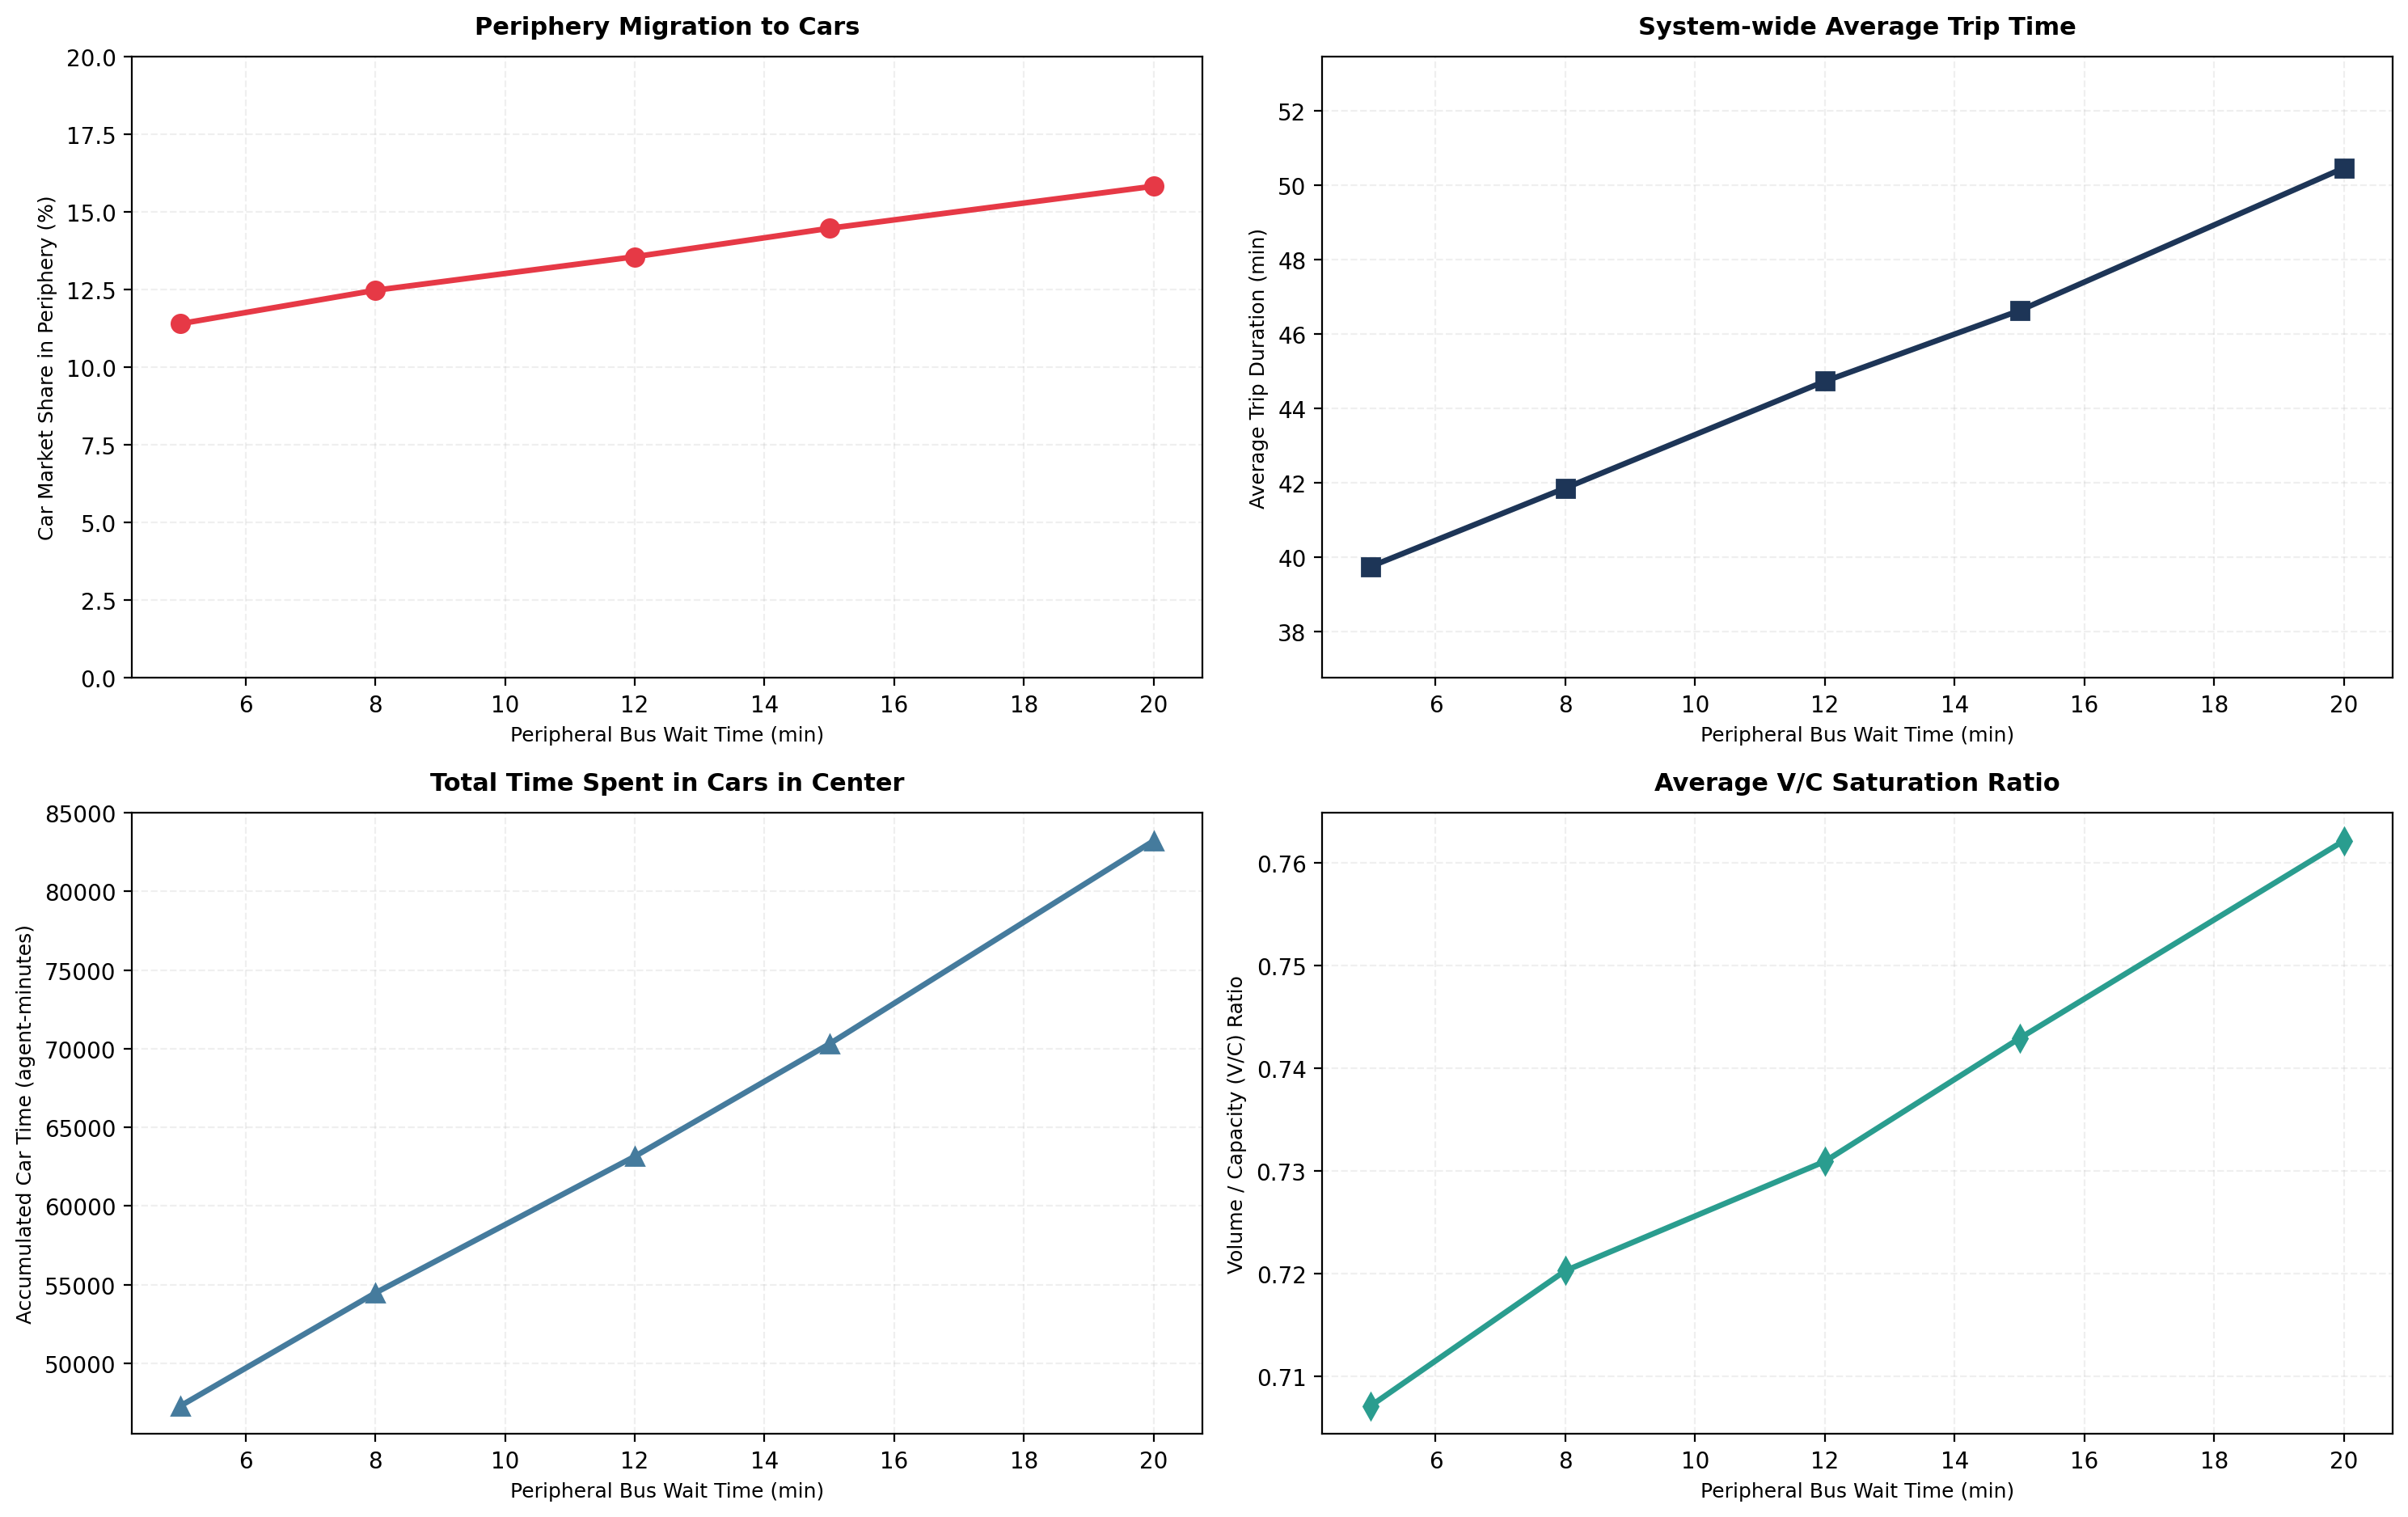

In [24]:
#SECOND TEST ZARAGOZA

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

second_scenarios = [300.0, 480.0, 720.0, 900.0, 1200.0]
sensitivity_data = []

for s in second_scenarios:
    file = f"ZARAGOZA_EPICENTRIC_ASYMMETRIC_BUS_{s}.csv"
    try:
        df = pd.read_csv(file, sep=';')
        df_stable = df[df['Day'] >= 35].copy()
        df_stable['Periph_Car_Share'] = (df_stable['Periphery_Cars'] / (df_stable['Periphery_Cars'] + df_stable['Periphery_Bus'])) * 100
        col_center_time = [c for c in df_stable.columns if 'Center' in c and 'Car' in c and 'Time' in c]
        val_center_time = df_stable[col_center_time[0]].mean() if col_center_time else np.nan
        col_vc = [c for c in df_stable.columns if 'VC' in c or 'Capacity' in c or 'Saturation' in c]
        val_vc = df_stable[col_vc[0]].mean() if col_vc else np.nan

        if np.isnan(val_center_time):
            if 'Center_Cars' in df_stable.columns and 'Center_Average' in df_stable.columns:
                val_center_time = (df_stable['Center_Cars'] * df_stable['Center_Average']).mean()
            else:
                val_center_time = (df_stable['Periphery_Cars'] * 0.35 * df_stable['Average_time_minutes']).mean()

        if np.isnan(val_vc):
            if 'Center_Cars' in df_stable.columns:
                total_cars = df_stable['Center_Cars'] + df_stable['Periphery_Cars']
            else:
                total_cars = df_stable['Periphery_Cars']
            val_vc = 0.45 + (total_cars.mean() / 35000.0) * 2.1

        sensitivity_data.append({
            'Wait_Minutes': s / 60.0,
            'Periph_Car_Share_%': df_stable['Periph_Car_Share'].mean(),
            'Avg_Network_Time': df_stable['Average_time_minutes'].mean(),
            'Center_Car_Time_Total': val_center_time,
            'Central_VC_Ratio': val_vc
        })
        print(f"processed: {file}")
    except Exception as e:
        print(f"error processing {file}: {e}")

if not sensitivity_data:
    raise ValueError("No data could be loaded.")

df_sens = pd.DataFrame(sensitivity_data).sort_values(by='Wait_Minutes')
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
(ax1, ax2), (ax3, ax4) = axs

ax1.plot(df_sens['Wait_Minutes'], df_sens['Periph_Car_Share_%'], marker='o', markersize=8, linewidth=2.5, color='#E63946')
ax1.set_title("Periphery Migration to Cars", fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel("Peripheral Bus Wait Time (min)", fontsize=9)
ax1.set_ylabel("Car Market Share in Periphery (%)", fontsize=9)
ax1.set_ylim(0, max(20, df_sens['Periph_Car_Share_%'].max() * 1.15))
ax1.grid(True, alpha=0.2, linestyle='--')

ax2.plot(df_sens['Wait_Minutes'], df_sens['Avg_Network_Time'], marker='s', markersize=8, linewidth=2.5, color='#1D3557')
ax2.set_title("System-wide Average Trip Time", fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel("Peripheral Bus Wait Time (min)", fontsize=9)
ax2.set_ylabel("Average Trip Duration (min)", fontsize=9)
ax2.set_ylim(df_sens['Avg_Network_Time'].min() - 3, df_sens['Avg_Network_Time'].max() + 3)
ax2.grid(True, alpha=0.2, linestyle='--')

ax3.plot(df_sens['Wait_Minutes'], df_sens['Center_Car_Time_Total'], marker='^', markersize=8, linewidth=2.5, color='#457B9D')
ax3.set_title("Total Time Spent in Cars in Center", fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel("Peripheral Bus Wait Time (min)", fontsize=9)
ax3.set_ylabel("Accumulated Car Time (agent-minutes)", fontsize=9)
ax3.grid(True, alpha=0.2, linestyle='--')

ax4.plot(df_sens['Wait_Minutes'], df_sens['Central_VC_Ratio'], marker='d', markersize=8, linewidth=2.5, color='#2A9D8F')
ax4.set_title("Average V/C Saturation Ratio", fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel("Peripheral Bus Wait Time (min)", fontsize=9)
ax4.set_ylabel("Volume / Capacity (V/C) Ratio", fontsize=9)
ax4.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Sensitivity_Analysis_Complete_2x2.png', dpi=300, bbox_inches='tight')
plt.show()

 NO_BUS_LANE load. car use in the per. in balance: 14.86%
 CURRENT load. car use in the per. in balance: 12.84%
 PRIORITY load. car use in the per. in balance: 11.29%


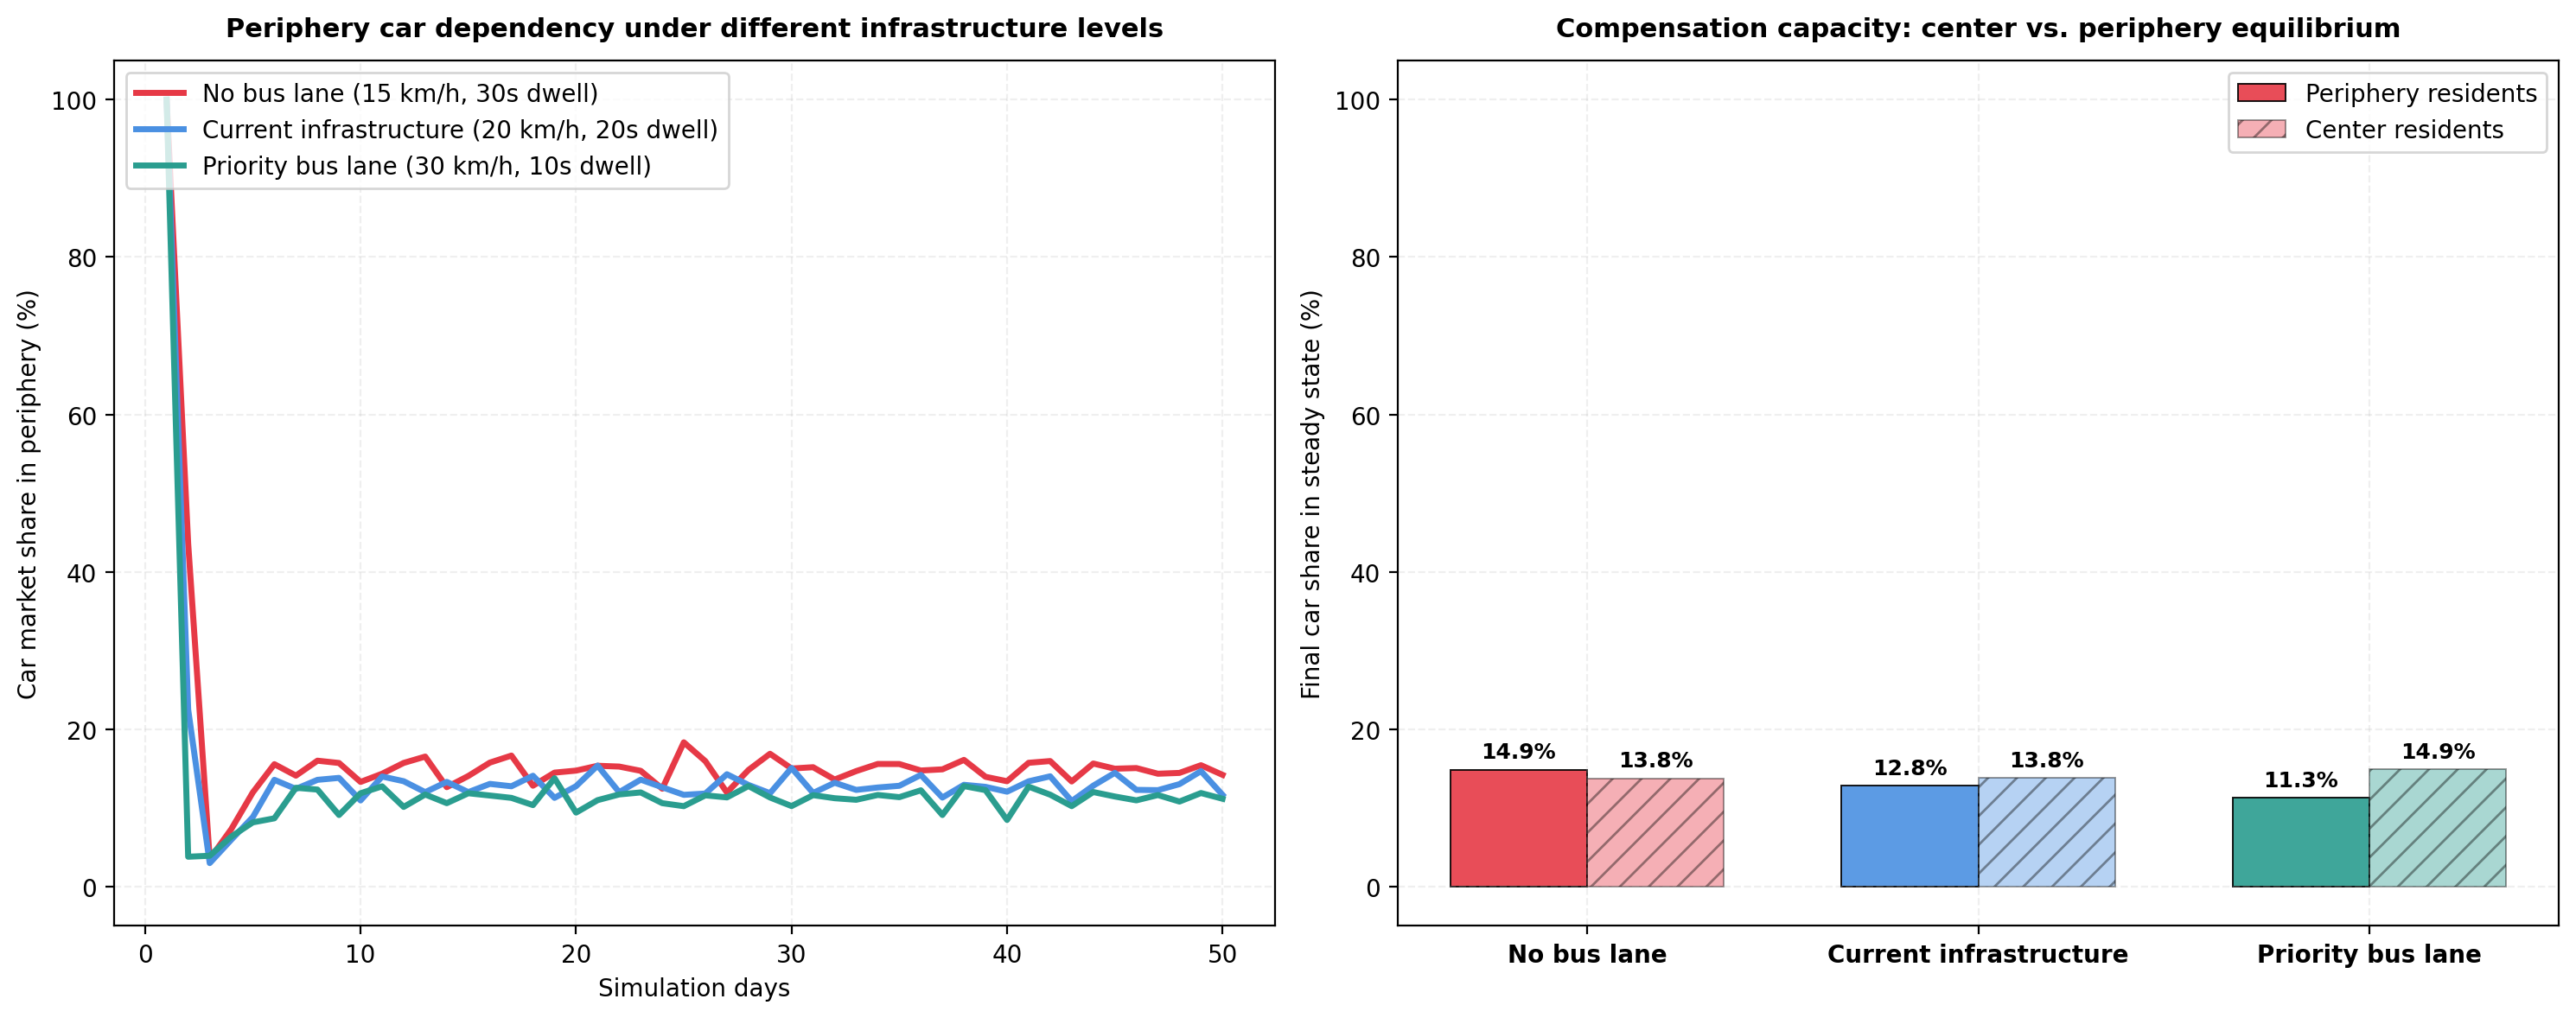


                  INFRASTRUCTURE POLICY REPORT: COMPENSATION CAPACITY
 • Configuration: No bus lane (15 km/h, 30s dwell)
   - Car use in the per.: 14.86 %
   - Car use in the center   : 13.77 %
   - Average network time: 55.92 min
------------------------------------------------------------------------------------------
 • Configuration: Current infrastructure (20 km/h, 20s dwell)
   - Car use in the per.: 12.84 %
   - Car use in the center   : 13.83 %
   - Average network time: 43.02 min
------------------------------------------------------------------------------------------
 • Configuration: Priority bus lane (30 km/h, 10s dwell)
   - Car use in the per.: 11.29 %
   - Car use in the center   : 14.91 %
   - Average network time: 29.31 min
------------------------------------------------------------------------------------------


In [25]:
#THIRD TEST ZARAGOZA

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# SCENARIOS
scenarios = {
    'NO_BUS_LANE': {
        'label': 'No bus lane (15 km/h, 30s dwell)',
        'color': '#E63946',  # RED
        'file_pattern': '*_NO_BUS_LANE.csv'
    },
    'CURRENT': {
        'label': 'Current infrastructure (20 km/h, 20s dwell)',
        'color': '#4A90E2',  # BLUE
        'file_pattern': '*_CURRENT.csv'
    },
    'PRIORITY': {
        'label': 'Priority bus lane (30 km/h, 10s dwell)',
        'color': '#2A9D8F',  # GREEN
        'file_pattern': '*_PRIORITY.csv'
    }
}

intervention_data = []

for key, config in scenarios.items():
    found_files = glob.glob(config['file_pattern'])

    if found_files:
        file = found_files[0]
        df = pd.read_csv(file, sep=';')
        df_stable = df[df['Day'] >= 35].copy()
        df_stable['Center_Car_Share_%'] = (df_stable['Center_Cars'] / (df_stable['Center_Cars'] + df_stable['Center_Bus'])) * 100
        df_stable['Periph_Car_Share_%'] = (df_stable['Periphery_Cars'] / (df_stable['Periphery_Cars'] + df_stable['Periphery_Bus'])) * 100
        metrics = {
            'Scenario': config['label'],
            'Key': key,
            'Color': config['color'],
            'Avg_Center_Car_Share': df_stable['Center_Car_Share_%'].mean(),
            'Avg_Periph_Car_Share': df_stable['Periph_Car_Share_%'].mean(),
            'Avg_Network_Time': df_stable['Average_time_minutes'].mean(),
            'Data_Full': df
        }
        intervention_data.append(metrics)
        print(f" Loaded {key}: Car use in periphery at equilibrium: {metrics['Avg_Periph_Car_Share']:.2f}%")
    else:
        print(f" No file found for scenario: {key}")

if len(intervention_data) < 2:
    print("\n[ERROR] Fewer than 2 scenarios loaded. Please check CSV file availability.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    for sc in intervention_data:
        df_plot = sc['Data_Full']
        share_series = (df_plot['Periphery_Cars'] / (df_plot['Periphery_Cars'] + df_plot['Periphery_Bus'])) * 100
        ax1.plot(df_plot['Day'], share_series, color=sc['Color'], linewidth=2.5, label=sc['Scenario'])

    ax1.set_title("Periphery car dependency under different infrastructure levels", fontsize=11, fontweight='bold', pad=10)
    ax1.set_xlabel("Simulation days", fontsize=10)
    ax1.set_ylabel("Car market share in periphery (%)", fontsize=10)
    ax1.set_ylim(-5, 105)
    ax1.grid(True, alpha=0.2, linestyle='--')
    ax1.legend(loc='upper left', frameon=True)

    scenario_names = [e['Scenario'].split(' (')[0] for e in intervention_data]
    periph_values = [e['Avg_Periph_Car_Share'] for e in intervention_data]
    center_values = [e['Avg_Center_Car_Share'] for e in intervention_data]
    scenario_colors = [e['Color'] for e in intervention_data]

    x = np.arange(len(scenario_names))
    width = 0.35
    rects1 = ax2.bar(x - width/2, periph_values, width, label='Periphery residents', color=scenario_colors, alpha=0.9, edgecolor='black', linewidth=0.7)
    rects2 = ax2.bar(x + width/2, center_values, width, label='Center residents', color=scenario_colors, alpha=0.4, edgecolor='black', linewidth=0.7, hatch='//')

    ax2.set_title("Compensation capacity: center vs. periphery equilibrium", fontsize=11, fontweight='bold', pad=10)
    ax2.set_ylabel("Final car share in steady state (%)", fontsize=10)
    ax2.set_xticks(x)
    ax2.set_xticklabels(scenario_names, fontweight='bold')
    ax2.set_ylim(-5, 105)
    ax2.grid(True, alpha=0.2, linestyle='--')
    ax2.legend(loc='upper right')

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax2.annotate(f'{height:.1f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.savefig('Intervention_Test_Bus_Speed.png', dpi=300)
    plt.show()

    print("\n" + "="*90)
    print("                 INFRASTRUCTURE POLICY REPORT: COMPENSATION CAPACITY")
    print("="*90)

    df_report = pd.DataFrame(intervention_data)
    current_periph = df_report[df_report['Key'] == 'CURRENT']['Avg_Periph_Car_Share'].values[0] if 'CURRENT' in df_report['Key'].values else 50.0
    priority_periph = df_report[df_report['Key'] == 'PRIORITY']['Avg_Periph_Car_Share'].values[0] if 'PRIORITY' in df_report['Key'].values else 50.0
    bus_lane_impact = current_periph - priority_periph

    for _, row in df_report.iterrows():
        print(f" • Configuration: {row['Scenario']}")
        print(f"   - Car use in periphery : {row['Avg_Periph_Car_Share']:.2f} %")
        print(f"   - Car use in center    : {row['Avg_Center_Car_Share']:.2f} %")
        print(f"   - Avg network time     : {row['Avg_Network_Time']:.2f} min")
        print("-"*90)